# Dispersion Bias, Part (ii) — heavy-tailed (ex-2 v2)

Stripped rebuild of `ex-2_heavy_tail`, extended to a full **pathwise** decomposition of the
Eq. (6) / eq. (18) error into its two components.

Each estimated direction $h_j$ splits across the population subspace and its complement,
$1 = \lVert h_j\rVert^2 = \lVert\Pi h_j\rVert^2 + \lVert\Pi^{\perp}h_j\rVert^2$, where
$\Pi$ projects onto $\mathrm{col}(b)$. The theorem pins both pieces as $p\to\infty$:

$$\underbrace{\lVert\Pi^{\perp}h_j\rVert^2}_{\text{out-of-subspace}} \to \frac{\delta^2}{n\lambda_j^{(n)}+\delta^2}=\text{floor},
\qquad
\underbrace{\sin^2_j-\lVert\Pi^{\perp}h_j\rVert^2}_{\text{in-subspace}} \to
\underbrace{\frac{n\rho_j}{n\rho_j+\delta^2}}_{\text{weight}}\cdot
\underbrace{\sin^2\angle(\hat w_j, e_j)}_{\text{rot}_j}.$$

The five figure rows, per factor (all difference/level rows are **per-replicate**):

1. **band** — mean $\sin^2\angle(h_j,\bar b_j)$ = out-of-subspace (floor) + in-subspace stack, measured line;
2. **gap** — $\sin^2_j - \text{rhs}$;
3. **out-of-subspace** — $\lVert\Pi^{\perp}h_j\rVert^2 - \text{floor}$;
4. **rotation** — $\text{rot}_j = \sin^2\angle(\hat w_j, e_j)$ itself ($\hat w_j$ = eigenvector of
   $\hat D$, $e_j$ = axis $j$); a level in $[0,1]$, ≈flat in $p$, $\to 0$ in $n$;
5. **in-subspace** — $\big(\sin^2_j-\lVert\Pi^{\perp}h_j\rVert^2\big) - \text{weight}\cdot\text{rot}_j$.

Per replicate, gap (row 2) = out-of-subspace (row 3) + in-subspace (row 5), so the two
components partition the total error exactly.

`DispersionBiasExperiment` does **not** record $\lVert\Pi^{\perp}h_j\rVert^2$, so we run the
sweeps with `MeasuredDecompositionExperiment` (carried verbatim from ex-3), a strict superset.
Same model / designs / seed as ex-2.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_graphics import (_np_top_panel, _np_gap_box_panel, _np_summarize,
                         _NP_COLORS, _NP_NAVY, _NP_GRAY, _NP_SIN2_TICKS)

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_ret_lab = rf"$\mathcal{{T}}_{HEAVY_TAIL['factor_return_sampler']['df']}$"
_idio_lab = rf"$\mathcal{{T}}_{HEAVY_TAIL['idio_return_sampler']['df']}$"
print("ready")

ready


In [ ]:
# ── Measured-decomposition machinery, carried verbatim from ex-3 (no .py files touched) ──
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class ObservableSpectrumAnalysis:
    """Observable side of Corollary 1: eigendecompose the n×n Gram G = Y^T Y, keep the full
    spectrum for the bulk average ℓ, and the top-k spikes θ_j (dual rescaled by 1/(n·p))."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)

        dual = eigenvalues[order] / (n * p)
        theta = dual[:k]
        bulk = dual[k:n - 1] if self.center else dual[k:]
        ell = float(bulk.mean())
        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": theta,
                "sample_bulk_eigenvalue_average_ell": ell,
                "observable_floor_estimate": ell / theta}


class ObservableFloorExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j": float(merged["sin2_j"][j]), "rhs": float(merged["rhs"][j]),
             "gap": float(gap[j]), "floor": float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]), "rho": float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue": float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average": float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate": float(merged["observable_floor_estimate"][j])}
            for j in range(k)]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Adds the finite-p eq.(18) split: ‖Π⊥h_j‖² via projection of h_j onto col(b_pop)."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        coeffs = self.population_loading_directions_b_pop @ H           # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        result["measured_out_of_subspace"] = 1.0 - in_subspace          # ‖Π⊥h_j‖²
        result["measured_in_subspace"] = result["sin2_j"] - (1.0 - in_subspace)
        result["angle_in_subspace"] = np.arccos(np.abs(np.diag(coeffs)) / np.sqrt(in_subspace))     # ∠(Π h_j, b_j), radians

        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
            row["angle_in_subspace"] = float(merged["angle_in_subspace"][j])

        return rows

print("measured-decomposition classes defined")

measured-decomposition classes defined


In [ ]:
# ── Wiring check for angle_in_subspace, before paying for the full sweeps ──────
# eq.(16):  sin²∠(h_j, b_j) = sin²∠(h_j, B) + cos²∠(h_j, B)·sin²∠(Π h_j, b_j)
# with sin²∠(h_j, B) = ‖Π⊥h_j‖² = measured_out_of_subspace and cos²∠(h_j, B) = 1 − that.
# A mismatched diagonal index (the easy mistake) shows up here as a large residual.
_smoke = DesignSpec(n_values=[30], p_values=[200], n_reps=5, random_seed=SEED,
                    sampling="nested", nest_time=True, **HEAVY_TAIL)
_d = run_experiment(model, _smoke, MeasuredDecompositionExperiment(), progress=False)

_oos = _d["measured_out_of_subspace"]
_rhs16 = _oos + (1.0 - _oos) * np.sin(_d["angle_in_subspace"]) ** 2
print(f"eq.(16) max residual: {(_d['sin2_j'] - _rhs16).abs().max():.2e}   (expect ~1e-15)")
print(f"undefined angles (Π h_j = 0): {int(_d['angle_in_subspace'].isna().sum())}")
print("median ∠(Π h_j, b_j) by factor [deg]:")
print(np.degrees(_d.groupby("j")["angle_in_subspace"].median()).round(2))


In [3]:
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

df_p = run_experiment(model, design_p, MeasuredDecompositionExperiment(), progress=True)
df_n = run_experiment(model, design_n, MeasuredDecompositionExperiment(), progress=True)

# Persist so figures can be re-rendered without re-running the sweeps.
df_p.to_parquet(OUT_DIR / "ex2v2_df_p.parquet")
df_n.to_parquet(OUT_DIR / "ex2v2_df_n.parquet")

# eq.(18) sanity: sin2_j == measured_out_of_subspace + measured_in_subspace, per rep.
for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    recon = d["measured_out_of_subspace"] + d["measured_in_subspace"]
    print(f"{nm}: max |sin2_j - (oos + insub)| = {(d['sin2_j'] - recon).abs().max():.2e}")

replicate: 100%|██████████| 1000/1000 [00:27<00:00, 35.98rep/s]

growing-p: max |sin2_j - (oos + insub)| = 0.00e+00
growing-n: max |sin2_j - (oos + insub)| = 0.00e+00


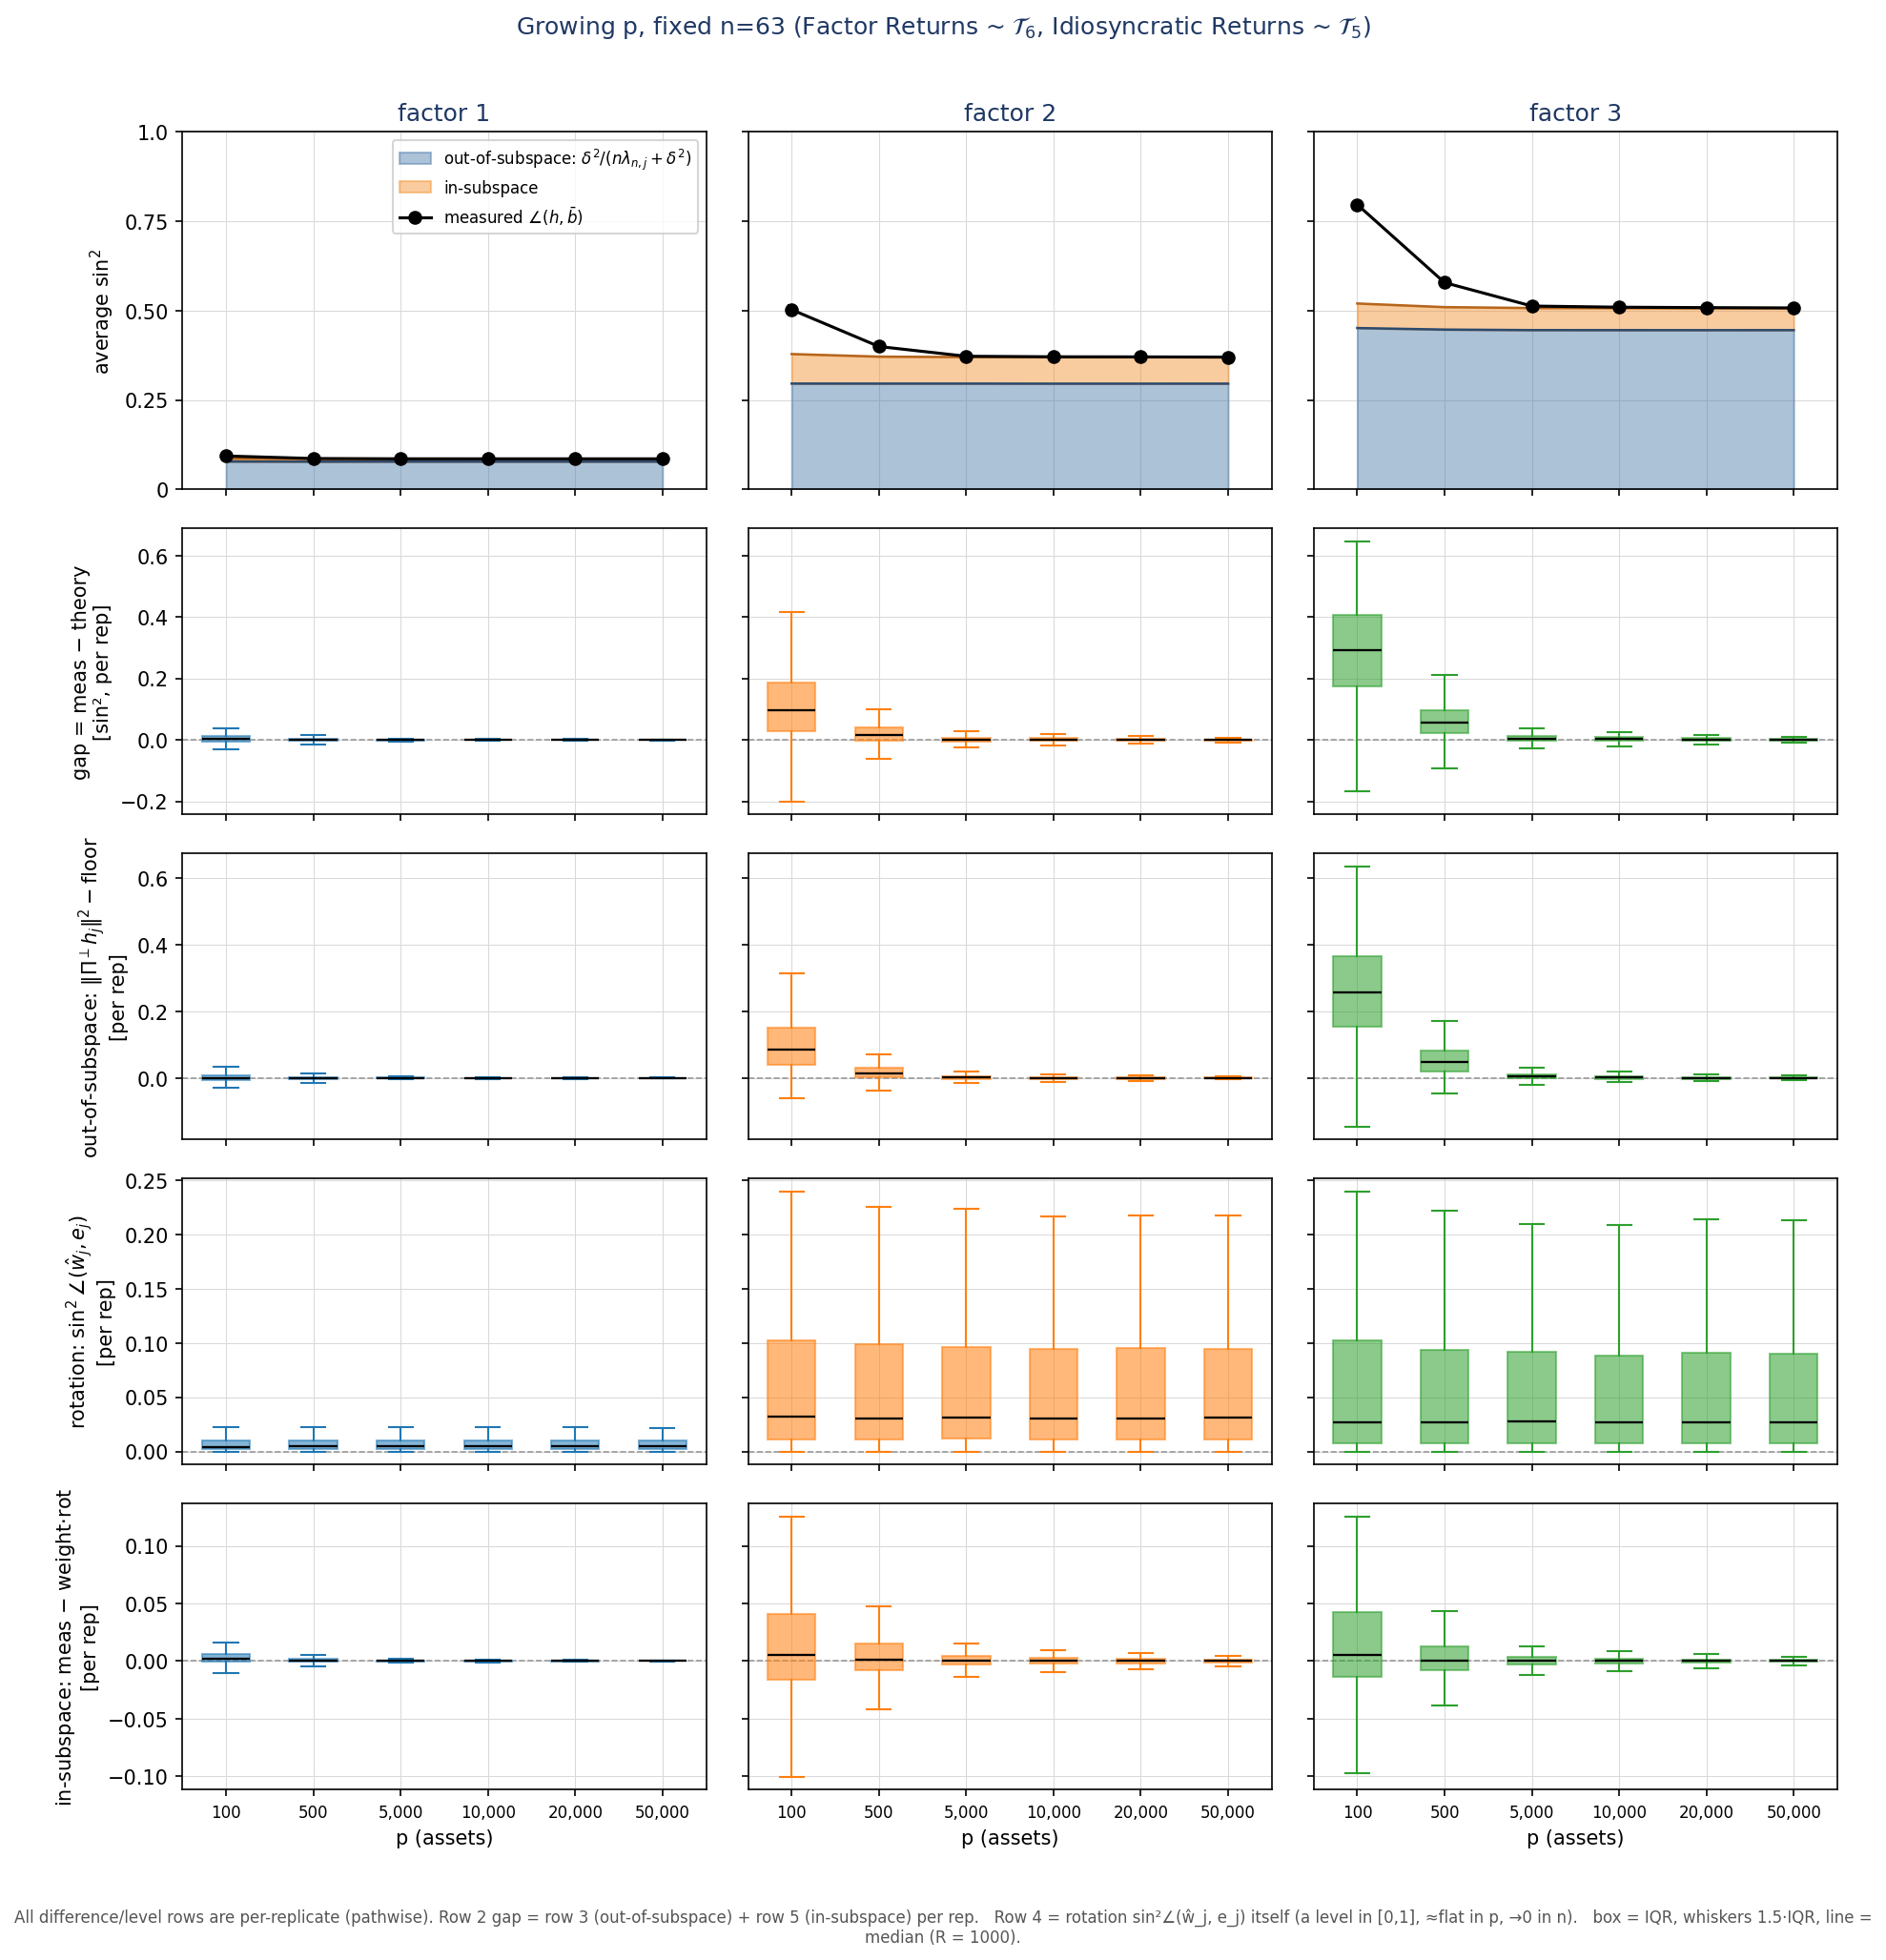

In [4]:
def five_row_decomposition(df, key, *, suptitle=None, out_path=None):
    """Band top row + four per-rep boxplot rows.

    Rows (all per-replicate, pathwise):
      0 band            — mean sin² = out-of-subspace + in-subspace stack, measured line
      1 gap             — sin²_j − rhs                    (total measured − theory)
      2 out-of-subspace — ‖Π⊥h_j‖² − floor
      3 rotation        — rot_j = sin²∠(ŵ_j, e_j) itself  (the level, not a difference)
      4 in-subspace     — measured_insub − weight·rot_j  (= meas_insub − (rhs − floor))
    Per rep gap = (row 2) + (row 4), so the two component differences partition the total.
    """
    order = sorted(df[key].unique())
    cats = [f"{v:,}" for v in order] if key == "p" else [str(v) for v in order]
    xlabel = "p (assets)" if key == "p" else "n (periods)"
    reps = int(df.groupby(["n", "p", "j"]).size().iloc[0])
    avg = _np_summarize(df, key)
    gap_all = df.assign(gap=df["sin2_j"] - df["rhs"])
    oos_all = df.assign(oos_gap=df["measured_out_of_subspace"] - df["floor"])
    # in-subspace error: measured (sin2_j − ‖Π⊥h‖²) minus theory limit weight·rot = (rhs − floor).
    ins_all = df.assign(ins_gap=df["measured_in_subspace"] - (df["rhs"] - df["floor"]))
    x = np.arange(len(cats))

    def _boxes(frame, col):
        return [frame[(frame["j"] == j) & (frame[key] == v)][col].to_numpy() for v in order]

    fig, axes = plt.subplots(5, 3, figsize=(13.3, 13.8), sharex="col", sharey="row",
                             gridspec_kw={"height_ratios": [1, 0.8, 0.8, 0.8, 0.8]})
    fig.subplots_adjust(left=0.10, right=0.97, top=0.93, bottom=0.09, hspace=0.13, wspace=0.08)
    for j in (1, 2, 3):
        a = avg[avg["j"] == j].set_index(key).loc[order]
        _np_top_panel(axes[0, j - 1], a, x, cats)
        axes[0, j - 1].set_title(f"factor {j}", color=_NP_NAVY)
        _np_gap_box_panel(axes[1, j - 1], _boxes(gap_all, "gap"), x, cats, _NP_COLORS[j - 1])
        _np_gap_box_panel(axes[2, j - 1], _boxes(oos_all, "oos_gap"), x, cats, _NP_COLORS[j - 1])
        _np_gap_box_panel(axes[3, j - 1], _boxes(df, "rotation"), x, cats, _NP_COLORS[j - 1])
        _np_gap_box_panel(axes[4, j - 1], _boxes(ins_all, "ins_gap"), x, cats, _NP_COLORS[j - 1])
        axes[4, j - 1].set_xlabel(xlabel)
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].set_yticks(*_NP_SIN2_TICKS)
    axes[0, 0].set_ylabel(r"average $\sin^2$")
    axes[1, 0].set_ylabel("gap = meas − theory\n[sin², per rep]")
    axes[2, 0].set_ylabel(r"out-of-subspace: $\Vert\Pi^{\perp}h_j\Vert^2 - $floor" + "\n[per rep]")
    axes[3, 0].set_ylabel(r"rotation: $\sin^2\angle(\hat w_j, e_j)$" + "\n[per rep]")
    axes[4, 0].set_ylabel(r"in-subspace: meas $-$ weight$\cdot$rot" + "\n[per rep]")
    axes[0, 0].legend(fontsize=8, loc="upper right")
    for ax in axes.flat:
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.label_outer()
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.99)
    fig.text(0.5, 0.03,
             "All difference/level rows are per-replicate (pathwise). "
             "Row 2 gap = row 3 (out-of-subspace) + row 5 (in-subspace) per rep.   "
             "Row 4 = rotation sin²∠(ŵ_j, e_j) itself (a level in [0,1], ≈flat in p, →0 in n).   "
             f"box = IQR, whiskers 1.5·IQR, line = median (R = {reps}).",
             ha="center", va="top", fontsize=8, color=_NP_GRAY, wrap=True)
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


_p_png = OUT_DIR / "ex2v2_fiverow_growing_p.png"
fig_p, _ = five_row_decomposition(
    df_p, "p", out_path=str(_p_png),
    suptitle=rf"Growing p, fixed n=63 (Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
fig_p.savefig(OUT_DIR / "ex2v2_fiverow_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_p_png)))
plt.close(fig_p)

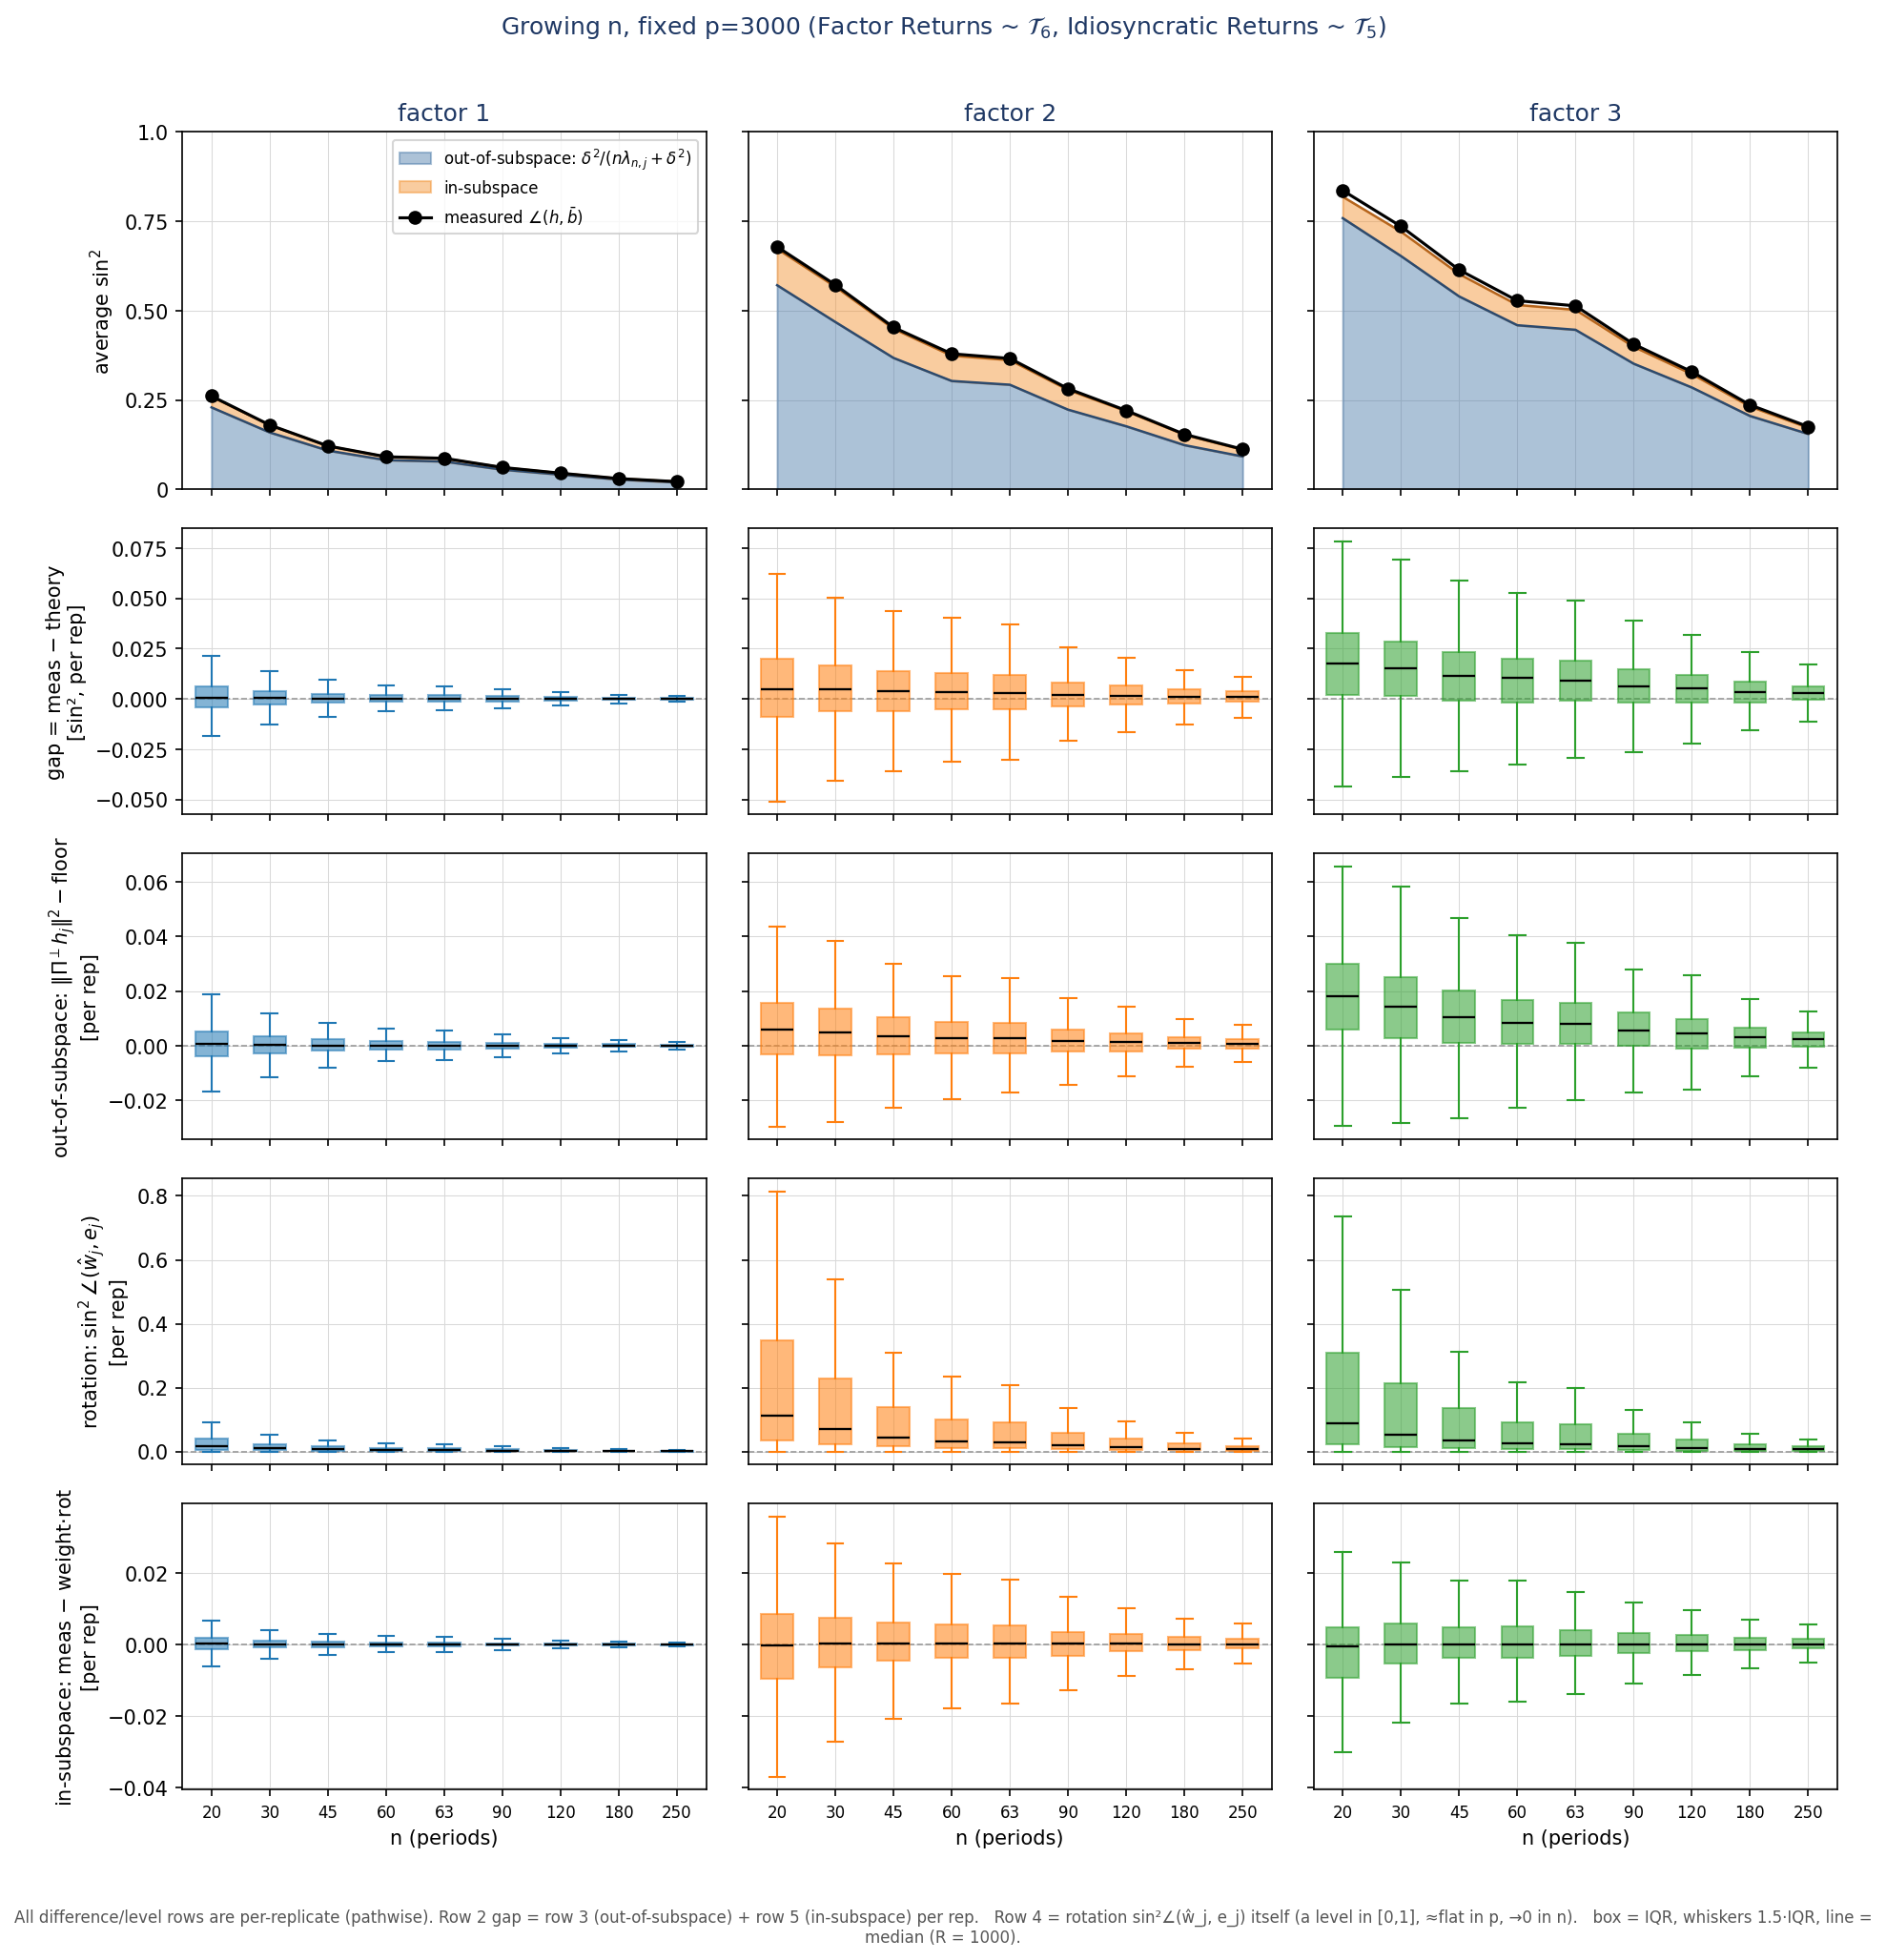

In [5]:
_n_png = OUT_DIR / "ex2v2_fiverow_growing_n.png"
fig_n, _ = five_row_decomposition(
    df_n, "n", out_path=str(_n_png),
    suptitle=rf"Growing n, fixed p=3000 (Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
fig_n.savefig(OUT_DIR / "ex2v2_fiverow_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_n_png)))
plt.close(fig_n)

## Numbers behind the component rows

Per-replicate median / Q1 / Q3 for the three lower rows — out-of-subspace difference
$\lVert\Pi^{\perp}h_j\rVert^2 - \text{floor}$, the rotation level $\text{rot}_j$, and the
in-subspace difference $(\sin^2_j - \lVert\Pi^{\perp}h_j\rVert^2) - \text{weight}\cdot\text{rot}_j$ —
per swept value and factor. The two difference columns shrink toward 0 (convergence); the
rotation level is roughly flat in $p$ and decays in $n$.

In [6]:
def component_table(df, key):
    g = df.assign(
        oos_diff=df["measured_out_of_subspace"] - df["floor"],
        rot=df["rotation"],
        insub_diff=df["measured_in_subspace"] - (df["rhs"] - df["floor"]),
    )
    parts = []
    for col in ("oos_diff", "rot", "insub_diff"):
        t = (g.groupby([key, "j"])[col]
               .agg(median="median", q1=lambda s: s.quantile(0.25),
                    q3=lambda s: s.quantile(0.75))
               .round(5))
        t.columns = pd.MultiIndex.from_product([[col], t.columns])
        parts.append(t)
    return pd.concat(parts, axis=1).reset_index().rename(columns={"j": "factor"})

print("Growing p (fixed n=63) — per-rep component summaries")
display(component_table(df_p, "p"))
print("Growing n (fixed p=3000) — per-rep component summaries")
display(component_table(df_n, "n"))

Growing p (fixed n=63) — per-rep component summaries


p factor oos_diff                        rot                    \
                   median       q1       q3   median       q1       q3   
0     100      1  0.00106 -0.00635  0.00954  0.00440  0.00194  0.01023   
1     100      2  0.08560  0.03920  0.15083  0.03199  0.01105  0.10259   
2     100      3  0.25858  0.15476  0.36661  0.02686  0.00751  0.10209   
3     500      1  0.00010 -0.00317  0.00382  0.00463  0.00201  0.01040   
4     500      2  0.01512  0.00216  0.03019  0.03069  0.01130  0.09894   
5     500      3  0.04903  0.02034  0.08176  0.02685  0.00755  0.09357   
6    5000      1  0.00002 -0.00110  0.00125  0.00464  0.00199  0.01013   
7    5000      2  0.00128 -0.00300  0.00583  0.03096  0.01155  0.09657   
8    5000      3  0.00463 -0.00146  0.01124  0.02754  0.00780  0.09148   
9   10000      1 -0.00001 -0.00079  0.00080  0.00463  0.00202  0.01017   
10  10000      2  0.00095 -0.00188  0.00391  0.03079  0.01146  0.09471   
11  10000      3  0.00222 -0.00171  0.00657  0.02674  0.00768  0.08834   
12  20000      1  0.00004 -0.00057  0.00058  0.00465  0.00203  0.01016   
13  20000      2  0.00053 -0.00167  0.00254  0.03071  0.01148  0.09556   
14  20000      3  0.00103 -0.00168  0.00406  0.02700  0.00771  0.09096   
15  50000      1  0.00002 -0.00036  0.00040  0.00462  0.00203  0.01022   
16  50000      2  0.00018 -0.00110  0.00140  0.03092  0.01144  0.09428   
17  50000      3  0.00042 -0.00136  0.00227  0.02691  0.00765  0.09011   

   insub_diff                    
       median       q1       q3  
0     0.00174 -0.00088  0.00596  
1     0.00549 -0.01588  0.04081  
2     0.00560 -0.01384  0.04246  
3     0.00032 -0.00078  0.00175  
4     0.00137 -0.00769  0.01548  
5     0.00067 -0.00825  0.01255  
6     0.00002 -0.00039  0.00046  
7     0.00026 -0.00291  0.00448  
8     0.00018 -0.00278  0.00353  
9    -0.00001 -0.00030  0.00028  
10    0.00018 -0.00234  0.00254  
11    0.00007 -0.00218  0.00222  
12    0.00000 -0.00020  0.00018  
13    0.00004 -0.00181  0.00180  
14    0.00001 -0.00149  0.00154  
15    0.00000 -0.00011  0.00012  
16   -0.00002 -0.00118  0.00110  
17   -0.00001 -0.00094  0.00102

Growing n (fixed p=3000) — per-rep component summaries


n factor oos_diff                        rot                    \
                 median       q1       q3   median       q1       q3   
0    20      1  0.00074 -0.00382  0.00519  0.01754  0.00584  0.04026   
1    20      2  0.00590 -0.00327  0.01579  0.11314  0.03623  0.34794   
2    20      3  0.01819  0.00584  0.02990  0.08742  0.02255  0.30919   
3    30      1  0.00020 -0.00260  0.00342  0.01038  0.00381  0.02378   
4    30      2  0.00494 -0.00343  0.01353  0.06990  0.02329  0.22939   
5    30      3  0.01425  0.00288  0.02504  0.05371  0.01416  0.21246   
6    45      1  0.00010 -0.00179  0.00230  0.00670  0.00277  0.01599   
7    45      2  0.00340 -0.00311  0.01030  0.04280  0.01760  0.13835   
8    45      3  0.01044  0.00093  0.02005  0.03481  0.01013  0.13542   
9    60      1  0.00012 -0.00128  0.00172  0.00469  0.00191  0.01120   
10   60      2  0.00286 -0.00280  0.00861  0.03215  0.01081  0.10026   
11   60      3  0.00820  0.00066  0.01665  0.02695  0.00751  0.09202   
12   63      1  0.00015 -0.00123  0.00154  0.00464  0.00179  0.01020   
13   63      2  0.00278 -0.00284  0.00827  0.02957  0.01113  0.09057   
14   63      3  0.00800  0.00083  0.01561  0.02394  0.00714  0.08450   
15   90      1 -0.00001 -0.00095  0.00109  0.00340  0.00129  0.00730   
16   90      2  0.00161 -0.00223  0.00585  0.02045  0.00723  0.05915   
17   90      3  0.00566 -0.00012  0.01204  0.01593  0.00505  0.05532   
18  120      1  0.00002 -0.00071  0.00081  0.00251  0.00101  0.00535   
19  120      2  0.00128 -0.00193  0.00465  0.01321  0.00440  0.04068   
20  120      3  0.00456 -0.00086  0.00991  0.01071  0.00333  0.03820   
21  180      1  0.00002 -0.00046  0.00056  0.00158  0.00062  0.00331   
22  180      2  0.00095 -0.00119  0.00322  0.00925  0.00345  0.02635   
23  180      3  0.00299 -0.00064  0.00654  0.00767  0.00267  0.02352   
24  250      1  0.00001 -0.00033  0.00041  0.00111  0.00044  0.00247   
25  250      2  0.00070 -0.00095  0.00255  0.00746  0.00274  0.01767   
26  250      3  0.00248 -0.00025  0.00497  0.00648  0.00205  0.01662   

   insub_diff                    
       median       q1       q3  
0     0.00018 -0.00140  0.00181  
1    -0.00026 -0.00968  0.00852  
2    -0.00041 -0.00921  0.00488  
3     0.00009 -0.00088  0.00111  
4     0.00019 -0.00639  0.00756  
5     0.00001 -0.00543  0.00600  
6     0.00007 -0.00070  0.00079  
7     0.00034 -0.00462  0.00629  
8     0.00004 -0.00381  0.00488  
9     0.00003 -0.00050  0.00065  
10    0.00035 -0.00369  0.00576  
11    0.00011 -0.00362  0.00497  
12    0.00002 -0.00045  0.00061  
13    0.00034 -0.00364  0.00528  
14    0.00014 -0.00328  0.00398  
15    0.00005 -0.00033  0.00043  
16    0.00025 -0.00309  0.00355  
17    0.00014 -0.00235  0.00330  
18    0.00002 -0.00026  0.00031  
19    0.00025 -0.00176  0.00305  
20    0.00005 -0.00185  0.00276  
21    0.00001 -0.00017  0.00021  
22    0.00010 -0.00150  0.00205  
23    0.00007 -0.00158  0.00186  
24    0.00002 -0.00012  0.00014  
25    0.00013 -0.00113  0.00170  
26    0.00010 -0.00103  0.00164

---
## Broken-out component figures

The five-row figure above, split into **four separate 2×3 figures** — one per quantity,
columns still factors 1–3. Every figure has the same shape:

* **top row** — the measured/realized **average** (black points, 95% CI caps) converging onto
  its **single theory mass** (orange line);
* **bottom row** — the **pathwise** per-replicate stats (boxplots).

Figure 1 (total) keeps the original first two rows verbatim — the stacked out-of-subspace +
in-subspace band. Figures 2–4 have a single-element top row, so there is one set of black
points converging to one line rather than a stack.

Each theory reference is abstracted from the limiting components. With
$\text{floor} = \delta^2/(n\rho_j+\delta^2)$,
$\text{weight} = n\rho_j/(n\rho_j+\delta^2) = 1-\text{floor}$, and
$\text{rhs} = \text{floor} + \text{weight}\cdot\text{rot}$:

| # | quantity | top: measured avg | top: theory mass | bottom: pathwise |
|---|---|---|---|---|
| 1 | total | $\sin^2_j$ | floor + in-subspace stack | $\sin^2_j-\text{rhs}$ |
| 2 | out-of-subspace | $\lVert\Pi^{\perp}h_j\rVert^2$ | $\text{floor}$ | $\lVert\Pi^{\perp}h_j\rVert^2-\text{floor}$ |
| 3 | rotation | $\sin^2\angle(\hat w_j,e_j)$ | — (single series) | per-rep rotation |
| 4 | in-subspace | $\sin^2_j-\lVert\Pi^{\perp}h_j\rVert^2$ | $\text{weight}\cdot\text{rot}=\text{rhs}-\text{floor}$ | measured $-$ weight·rot |

(equivalently $\text{rot} = (\text{rhs}-\text{floor})/(1-\text{floor})$ if it ever needs
backing out.) All eight figures render from the already-computed sweeps — no re-run.

In [7]:
from fl_graphics import six_panel_decomposition
from matplotlib.patches import Patch

_CAP = dict(fmt="none", ecolor="black", elinewidth=0.8, capsize=2, zorder=6)
# Same fills / toplines as the band top row of the 9-panel figure.
_OOS_FILL, _OOS_LINE = "#4878a8", "#2c4a6e"        # out-of-subspace (floor)
_INSUB_FILL, _INSUB_LINE = "#f28e2b", "#b5651d"    # in-subspace


def with_components(df):
    """Attach the theory limits + pathwise differences abstracted from the components."""
    return df.assign(
        theory_oos=df["floor"],                                   # oos limit
        theory_insub=df["rhs"] - df["floor"],                     # weight·rot
        diff_oos=df["measured_out_of_subspace"] - df["floor"],
        diff_insub=df["measured_in_subspace"] - (df["rhs"] - df["floor"]),
    )


def _band_top_panel(ax, x, cats, level, meas, meas_se, *, fill, topline):
    """Single-band version of fl_graphics._np_top_panel: one shaded band from 0 up to the
    theory `level` with its topline, and the measured mean (black dots + 95% CI caps) on top.
    y-limits are set once by the caller (the row is shared across factors)."""
    ax.fill_between(x, 0, level, color=fill, alpha=0.45, zorder=1)
    ax.plot(x, level, "-", color=topline, lw=1.2, zorder=3)
    ax.plot(x, meas, "o-", color="black", lw=1.2, zorder=5)
    ax.errorbar(x, meas, yerr=1.96 * meas_se, **_CAP)
    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(x, cats, fontsize=8)


def component_two_row(df, key, *, meas_col, diff_col, theory_col, top_ylabel, bottom_ylabel,
                      fill=_OOS_FILL, topline=_OOS_LINE, meas_label="measured (mean)",
                      theory_label="theory limit", suptitle=None, out_path=None):
    """2×3 component figure, same shape as figure 1's first two rows.

    Top row — one shaded band from 0 to the theory limit `theory_col` (mean over reps) with
    the measured mean `meas_col` (black dots, 95% CI caps) riding on it, exactly like the
    band top row of the 9-panel figure but with a single component instead of the stack.
    Bottom row — per-replicate (pathwise) boxplots of `diff_col`. Columns are factors 1-3.
    """
    order = sorted(df[key].unique())
    cats = [f"{v:,}" for v in order] if key == "p" else [str(v) for v in order]
    xlabel = "p (assets)" if key == "p" else "n (periods)"
    reps = int(df.groupby(["n", "p", "j"]).size().iloc[0])
    x = np.arange(len(cats))
    a_all = (df.groupby([key, "j"])
               .agg(m=(meas_col, "mean"), se=(meas_col, "sem"), t=(theory_col, "mean"))
               .reset_index())
    # Shared top-row limit computed across all three factors (sharey would otherwise lock
    # the row to whichever panel was drawn first).
    ymax = 1.06 * float(max(a_all["t"].max(), (a_all["m"] + 1.96 * a_all["se"]).max()))

    fig, axes = plt.subplots(2, 3, figsize=(13.3, 7.0), sharex="col", sharey="row",
                             gridspec_kw={"height_ratios": [1, 0.8]})
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.17, hspace=0.13, wspace=0.08)
    for j in (1, 2, 3):
        a = a_all[a_all["j"] == j].set_index(key).loc[order]
        _band_top_panel(axes[0, j - 1], x, cats, a["t"].to_numpy(),
                        a["m"].to_numpy(), a["se"].to_numpy(), fill=fill, topline=topline)
        axes[0, j - 1].set_title(f"factor {j}", color=_NP_NAVY)
        boxes = [df[(df["j"] == j) & (df[key] == v)][diff_col].to_numpy() for v in order]
        _np_gap_box_panel(axes[1, j - 1], boxes, x, cats, _NP_COLORS[j - 1])
        axes[1, j - 1].set_xlabel(xlabel)
    axes[0, 0].set_ylim(0, ymax)
    axes[0, 0].set_ylabel(top_ylabel)
    axes[1, 0].set_ylabel(bottom_ylabel)
    axes[0, 0].legend(handles=[
        Patch(facecolor=fill, alpha=0.45, edgecolor=topline, label=theory_label),
        plt.Line2D([], [], marker="o", color="black", lw=1.2, label=meas_label),
    ], fontsize=8, loc="upper right")
    for ax in axes.flat:
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.label_outer()
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.97)
    fig.text(0.5, 0.05,
             "Top — shaded band = theory limit (mean), black line = measured mean with "
             "95% CI caps; the measured line settles onto the band as the sweep grows.   "
             "Bottom — per-replicate (pathwise) difference: box = IQR, whiskers 1.5·IQR, "
             f"line = median (R = {reps}).",
             ha="center", va="top", fontsize=8, color=_NP_GRAY, wrap=True)
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


cdf_p, cdf_n = with_components(df_p), with_components(df_n)
_SWEEPS = [("p", cdf_p, rf"Growing p, fixed n=63"),
           ("n", cdf_n, rf"Growing n, fixed p=3000")]
_TAILS = rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})"
print("component helpers ready")

component helpers ready


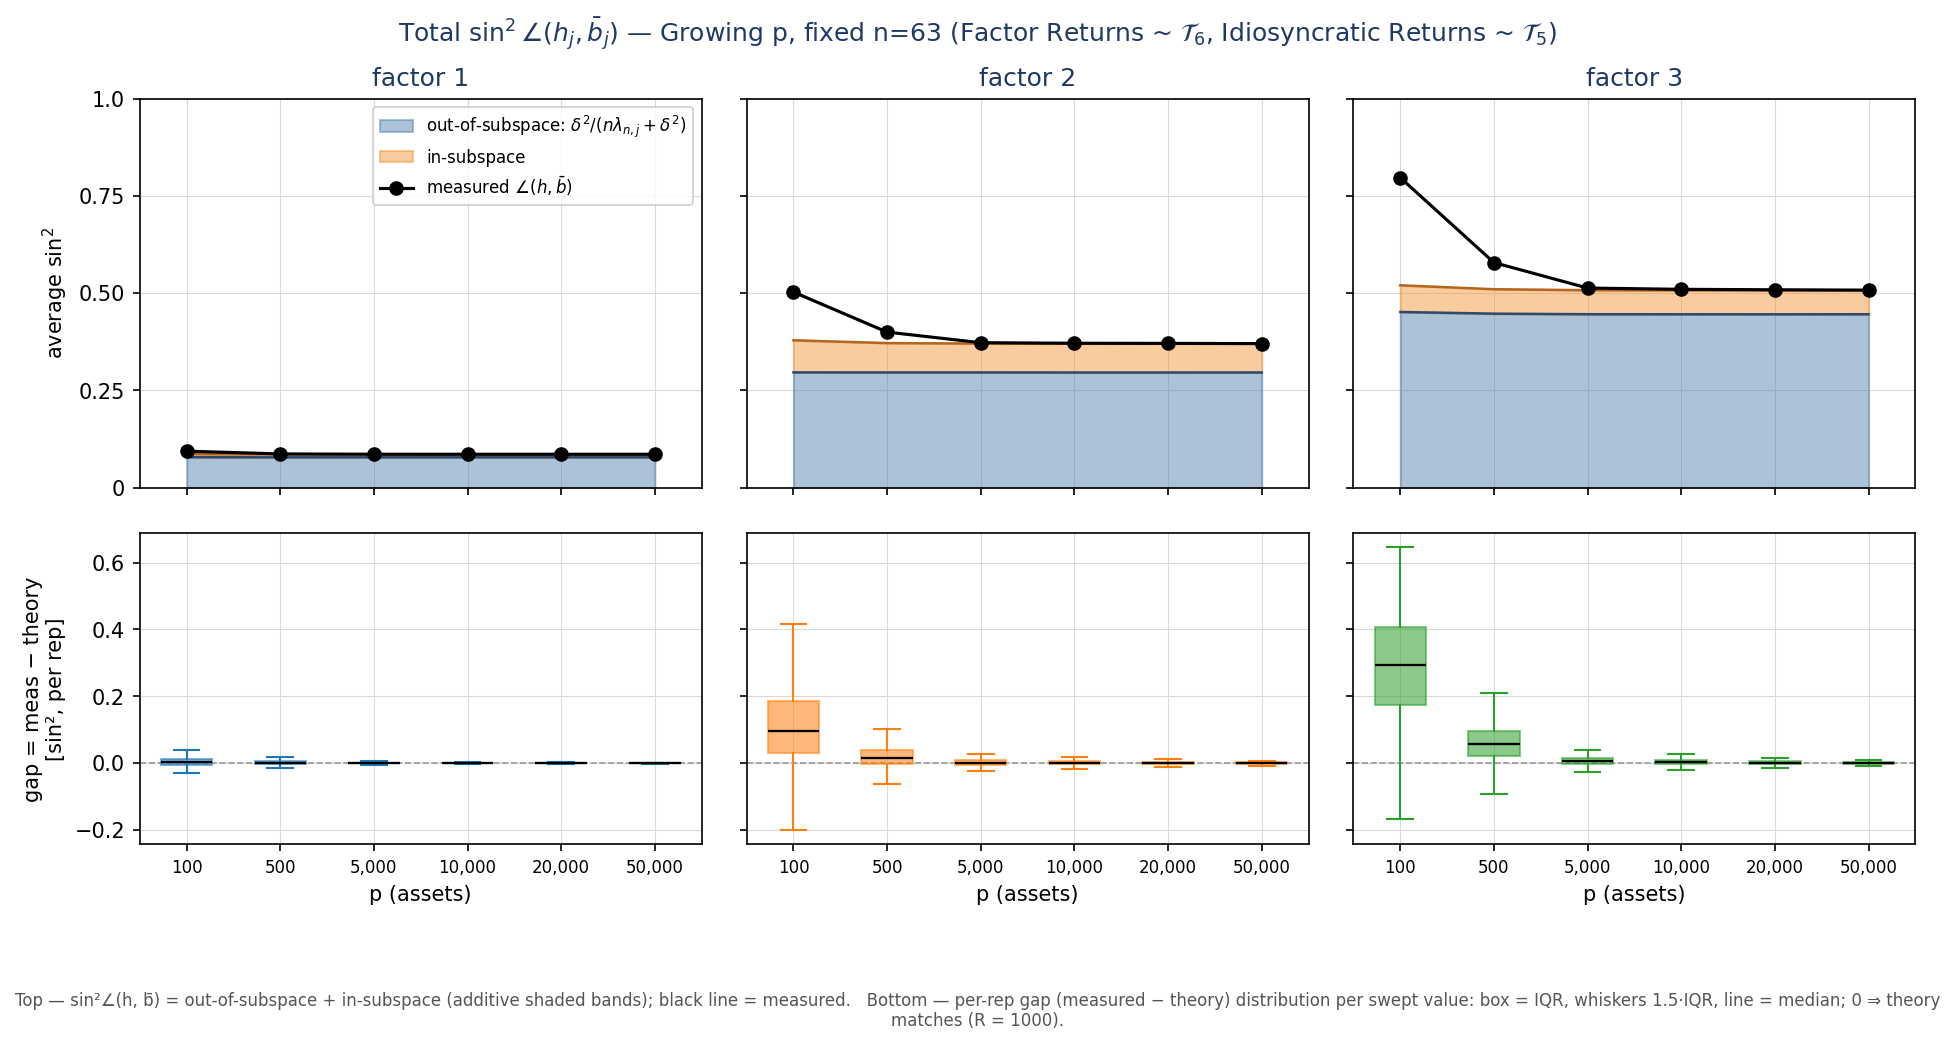

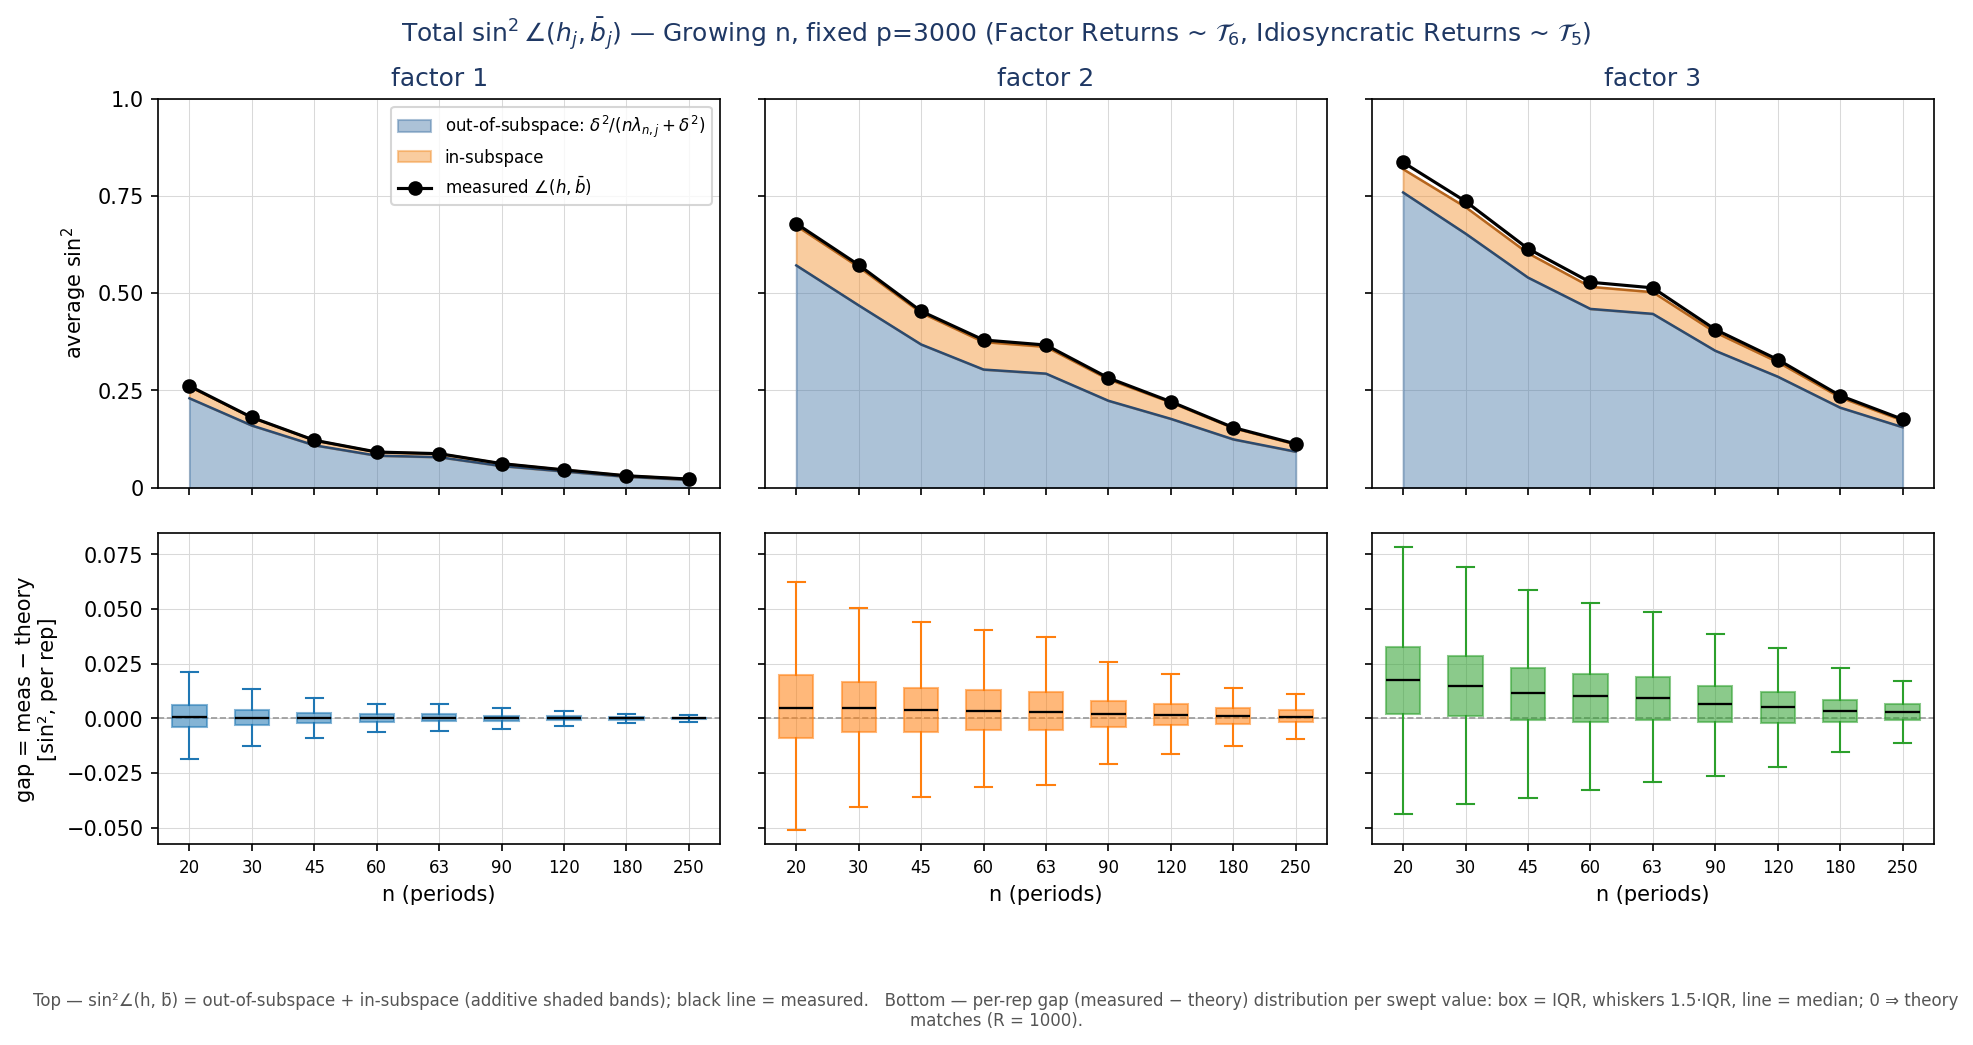

In [8]:
# ── Figure 1 of 4: TOTAL — original first two rows, kept verbatim ──────────────
# Band top row (stacked out-of-subspace + in-subspace) + per-rep gap boxplots, via the
# shared fl_graphics plotter so it cannot drift from the 9-panel/5-row versions.
for key, cdf, lab in _SWEEPS:
    _png = OUT_DIR / f"ex2v2_comp1_total_growing_{key}.png"
    fig, _ = six_panel_decomposition(
        cdf, key=key, out_path=str(_png),
        suptitle=rf"Total $\sin^2\angle(h_j,\bar b_j)$ — {lab} {_TAILS}")
    fig.savefig(OUT_DIR / f"ex2v2_comp1_total_growing_{key}.pdf", bbox_inches="tight")
    display(Image(filename=str(_png)))
    plt.close(fig)

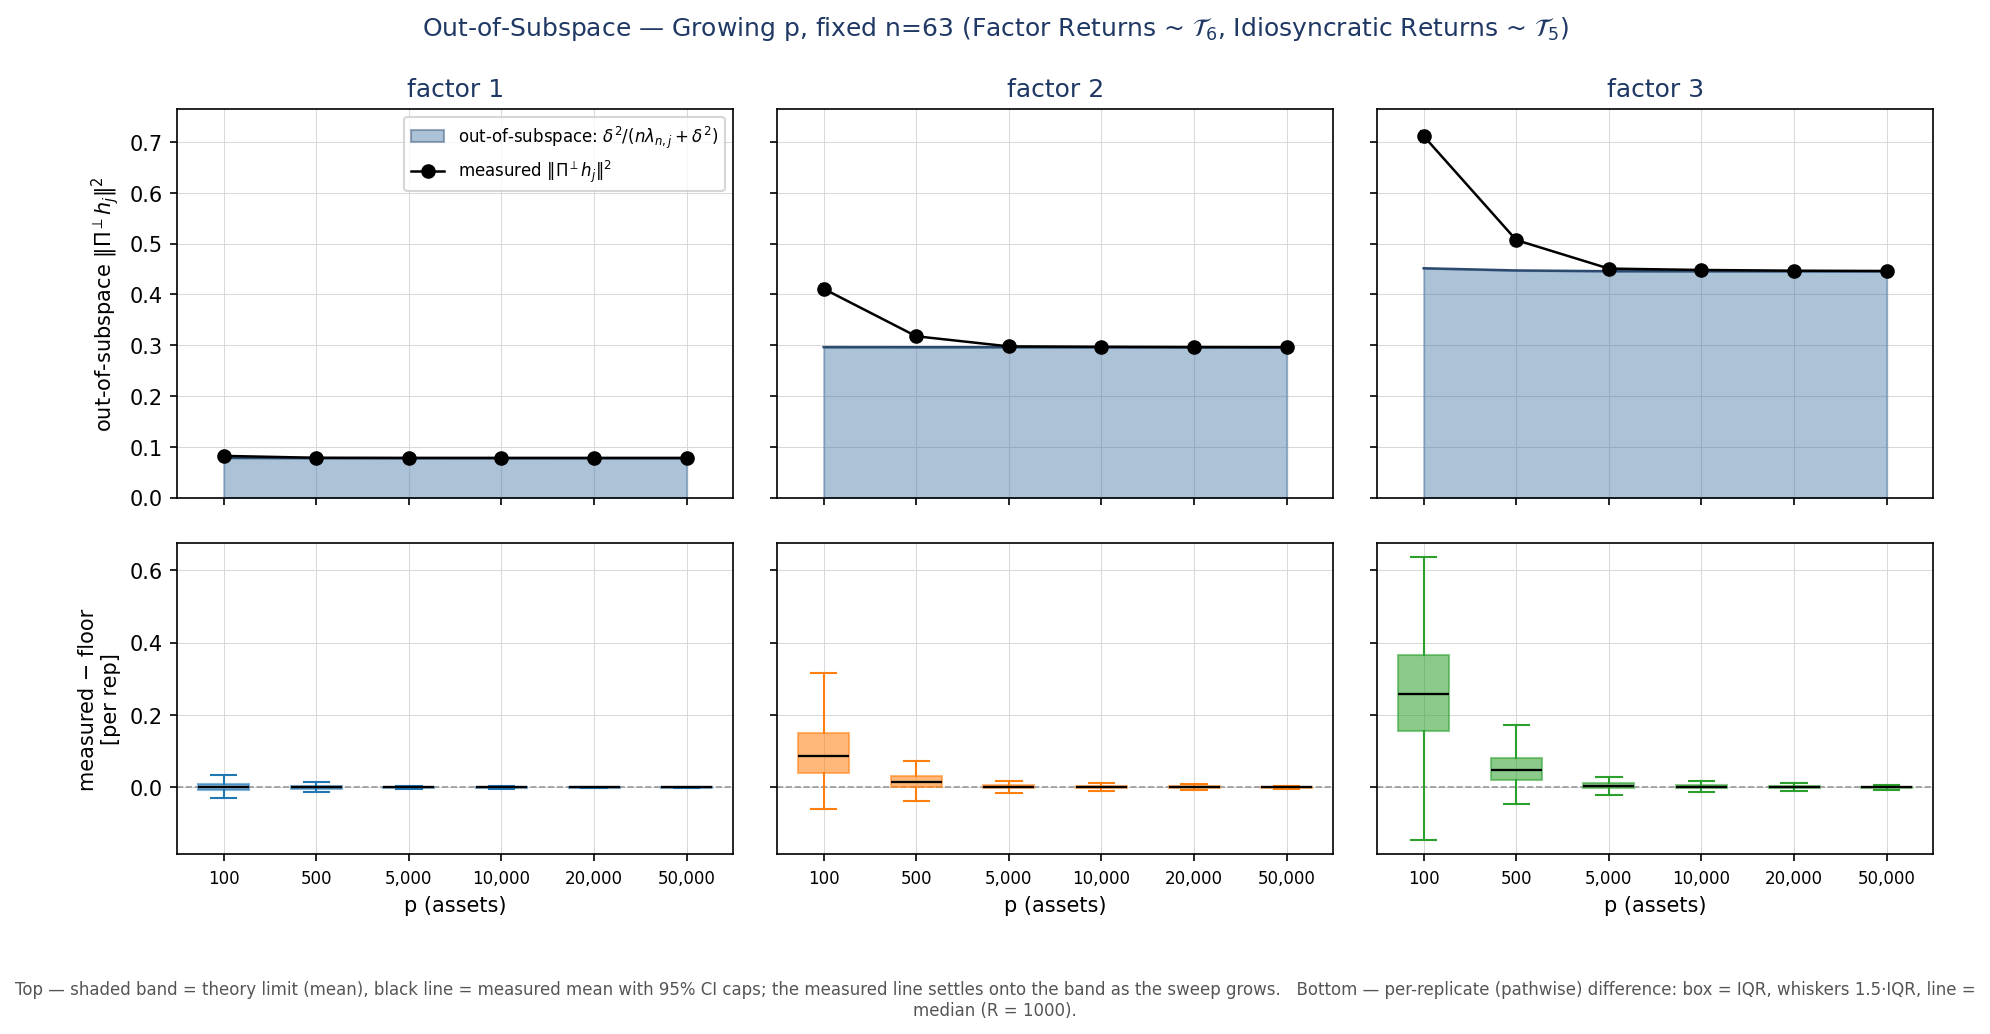

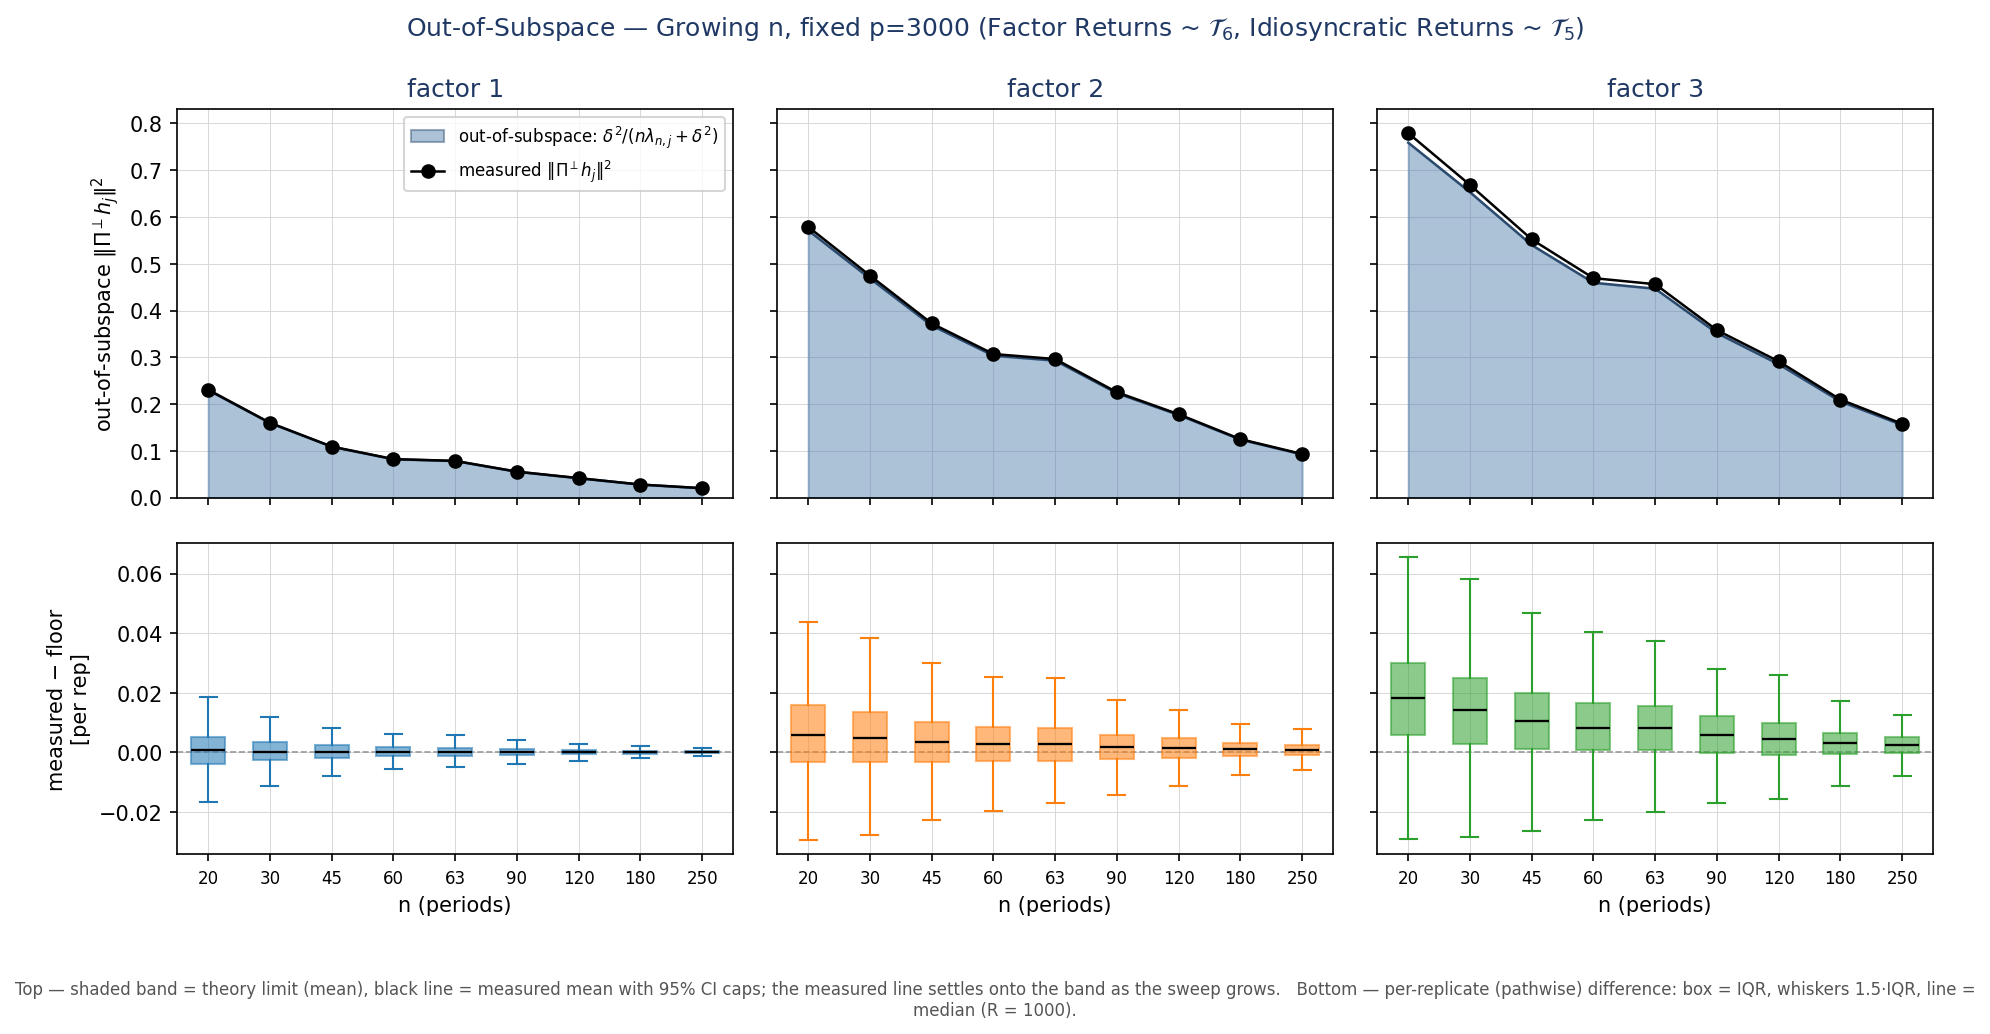

In [9]:
# ── Figure 2 of 4: OUT-OF-SUBSPACE — ‖Π⊥h_j‖² settling onto the floor band ────
for key, cdf, lab in _SWEEPS:
    _png = OUT_DIR / f"ex2v2_comp2_oos_growing_{key}.png"
    fig, _ = component_two_row(
        cdf, key,
        meas_col="measured_out_of_subspace", theory_col="theory_oos", diff_col="diff_oos",
        fill=_OOS_FILL, topline=_OOS_LINE,
        meas_label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$",
        theory_label=r"out-of-subspace: $\delta^2/(n\lambda_{n,j}+\delta^2)$",
        top_ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$",
        bottom_ylabel="measured − floor\n[per rep]",
        out_path=str(_png),
        suptitle=rf"Out-of-Subspace — {lab} {_TAILS}")
    fig.savefig(OUT_DIR / f"ex2v2_comp2_oos_growing_{key}.pdf", bbox_inches="tight")
    display(Image(filename=str(_png)))
    plt.close(fig)

In [ ]:
# ── Figure 3 of 4: ROTATION — sin²∠(ν̂_j, e_j); a measured level, no theory pair ──
# Rotation has no theory limit, so this figure does NOT use component_two_row: passing the
# same column as both `meas_col` and `theory_col` would draw the mean twice (black line lying
# exactly on the band topline) and label it "measured vs theory". Instead the top row shows the
# *distribution* of the level — Q1–Q3 band, median, and mean ± 95% CI — which also exposes how
# far the mean sits above the median (the per-rep distribution is strongly right-skewed, with
# replicates reaching ~1). Bottom row is the same per-rep level as boxplots.


def rotation_two_row(df, key, *, col="rotation", suptitle=None, out_path=None,
                     top_ylabel=r"rotation $\sin^2\angle(\hat \nu_j, e_j)$",
                     bottom_ylabel=r"$\sin^2\angle(\hat \nu_j, e_j)$" + "\n[per rep]",
                     quantity_note=("Rotation has no theory limit — it is a measured level in "
                                    "[0,1], so both rows show the same per-replicate quantity, "
                                    "not a measured-vs-theory pair."),
                     fill=_OOS_FILL, topline=_OOS_LINE):
    """2×3 distribution figure for a single measured level (no theory reference).

    Top row — shaded band = Q1–Q3 across replicates with its quartile toplines, heavy line =
    median, black dots = mean with 95% CI caps. Bottom row — the same per-replicate level as
    boxplots. Columns are factors 1–3, y shared per row.
    """
    order = sorted(df[key].unique())
    cats = [f"{v:,}" for v in order] if key == "p" else [str(v) for v in order]
    xlabel = "p (assets)" if key == "p" else "n (periods)"
    reps = int(df.groupby(["n", "p", "j"]).size().iloc[0])
    x = np.arange(len(cats))
    a_all = (df.groupby([key, "j"])[col]
               .agg(mean="mean", sem="sem", med="median",
                    q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
               .reset_index())
    # Shared top-row limit across all three factors: the band reaches Q3, the caps may go higher.
    ymax = 1.06 * float(max(a_all["q3"].max(), (a_all["mean"] + 1.96 * a_all["sem"]).max()))

    fig, axes = plt.subplots(2, 3, figsize=(13.3, 7.0), sharex="col", sharey="row",
                             gridspec_kw={"height_ratios": [1, 0.8]})
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.17, hspace=0.13, wspace=0.08)
    for j in (1, 2, 3):
        a = a_all[a_all["j"] == j].set_index(key).loc[order]
        ax = axes[0, j - 1]
        ax.fill_between(x, a["q1"], a["q3"], color=fill, alpha=0.45, zorder=1)
        ax.plot(x, a["q1"], "-", color=topline, lw=0.8, zorder=3)
        ax.plot(x, a["q3"], "-", color=topline, lw=0.8, zorder=3)
        ax.plot(x, a["med"], "-", color=topline, lw=2.0, zorder=4)
        ax.plot(x, a["mean"], "o-", color="black", lw=1.2, zorder=5)
        ax.errorbar(x, a["mean"], yerr=1.96 * a["sem"].to_numpy(), **_CAP)
        ax.set_xlim(x[0], x[-1])
        ax.set_xticks(x, cats, fontsize=8)
        ax.set_title(f"factor {j}", color=_NP_NAVY)
        levels = [df[(df["j"] == j) & (df[key] == v)][col].to_numpy() for v in order]
        _np_gap_box_panel(axes[1, j - 1], levels, x, cats, _NP_COLORS[j - 1])
        axes[1, j - 1].set_xlabel(xlabel)
    axes[0, 0].set_ylim(0, ymax)
    axes[0, 0].set_ylabel(top_ylabel)
    axes[1, 0].set_ylabel(bottom_ylabel)
    axes[0, 0].legend(handles=[
        Patch(facecolor=fill, alpha=0.45, edgecolor=topline, label="Q1–Q3 across replicates"),
        plt.Line2D([], [], color=topline, lw=2.0, label="median"),
        plt.Line2D([], [], marker="o", color="black", lw=1.2, label="mean ± 95% CI"),
    ], fontsize=8, loc="upper right")
    for ax in axes.flat:
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.label_outer()
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.97)
    fig.text(0.5, 0.05,
             f"{quantity_note}   "
             "Top — shaded band = Q1–Q3 across replicates, dark line = median, black dots = mean "
             "with 95% CI caps; the mean sits well above the median because the distribution is "
             "strongly right-skewed.   "
             f"Bottom — box = IQR, whiskers 1.5·IQR, line = median (R = {reps}).",
             ha="center", va="top", fontsize=8, color=_NP_GRAY, wrap=True)
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


for key, cdf, lab in _SWEEPS:
    _png = OUT_DIR / f"ex2v2_comp3_rotation_growing_{key}.png"
    fig, _ = rotation_two_row(cdf, key, out_path=str(_png),
                              suptitle=rf"Rotation — {lab} {_TAILS}")
    fig.savefig(OUT_DIR / f"ex2v2_comp3_rotation_growing_{key}.pdf", bbox_inches="tight")
    display(Image(filename=str(_png)))
    plt.close(fig)


In [ ]:
# ── Figure 3b: in-subspace rotation against its factor-space limit ────────────
#     sin²∠(Π h_j, b_j)  ⟶  sin²∠(ν_j^(n), e_j)
# The original two-row layout, but now with a genuine measured/theory pair instead of the
# same column passed twice: the measured quantity is the in-subspace rotation of the
# estimate, the reference is the k×k factor-space rotation it converges to as p grows at
# fixed n. Top — measured mean settling onto the limit band. Bottom — the per-replicate
# difference, which is the pathwise version of that statement and should collapse to 0.
#
# The measured column is recovered from what the sweep already records: the in-subspace
# angle is the total sin² with the out-of-subspace mass divided out,
#     sin²∠(Π h_j, b_j) = (sin²_j − ‖Π⊥h_j‖²) / (1 − ‖Π⊥h_j‖²).


def with_insub_rotation(df):
    """Attach the measured in-subspace rotation and its difference from the k×k limit."""
    oos = df["measured_out_of_subspace"]
    s = (df["sin2_j"] - oos) / (1.0 - oos)
    return df.assign(sin2_in=s, diff_in_rot=s - df["rotation"])


for key, cdf, lab in _SWEEPS:
    _png = OUT_DIR / f"ex2v2_comp3b_insub_vs_rotation_growing_{key}.png"
    fig, _ = component_two_row(
        with_insub_rotation(cdf), key,
        meas_col="sin2_in", theory_col="rotation", diff_col="diff_in_rot",
        fill=_OOS_FILL, topline=_OOS_LINE,
        meas_label=r"measured $\sin^2\angle(\Pi h_j, b_j)$",
        theory_label=r"limit $\sin^2\angle(\nu^{(n)}_j, e_j)$",
        top_ylabel=r"in-subspace rotation $\sin^2\angle(\Pi h_j, b_j)$",
        bottom_ylabel=r"$\sin^2\angle(\Pi h_j,b_j) - \sin^2\angle(\nu^{(n)}_j,e_j)$" + "\n[per rep]",
        out_path=str(_png),
        suptitle=rf"In-subspace rotation vs its factor-space limit — {lab} {_TAILS}")
    fig.savefig(OUT_DIR / f"ex2v2_comp3b_insub_vs_rotation_growing_{key}.pdf", bbox_inches="tight")
    display(Image(filename=str(_png)))
    plt.close(fig)


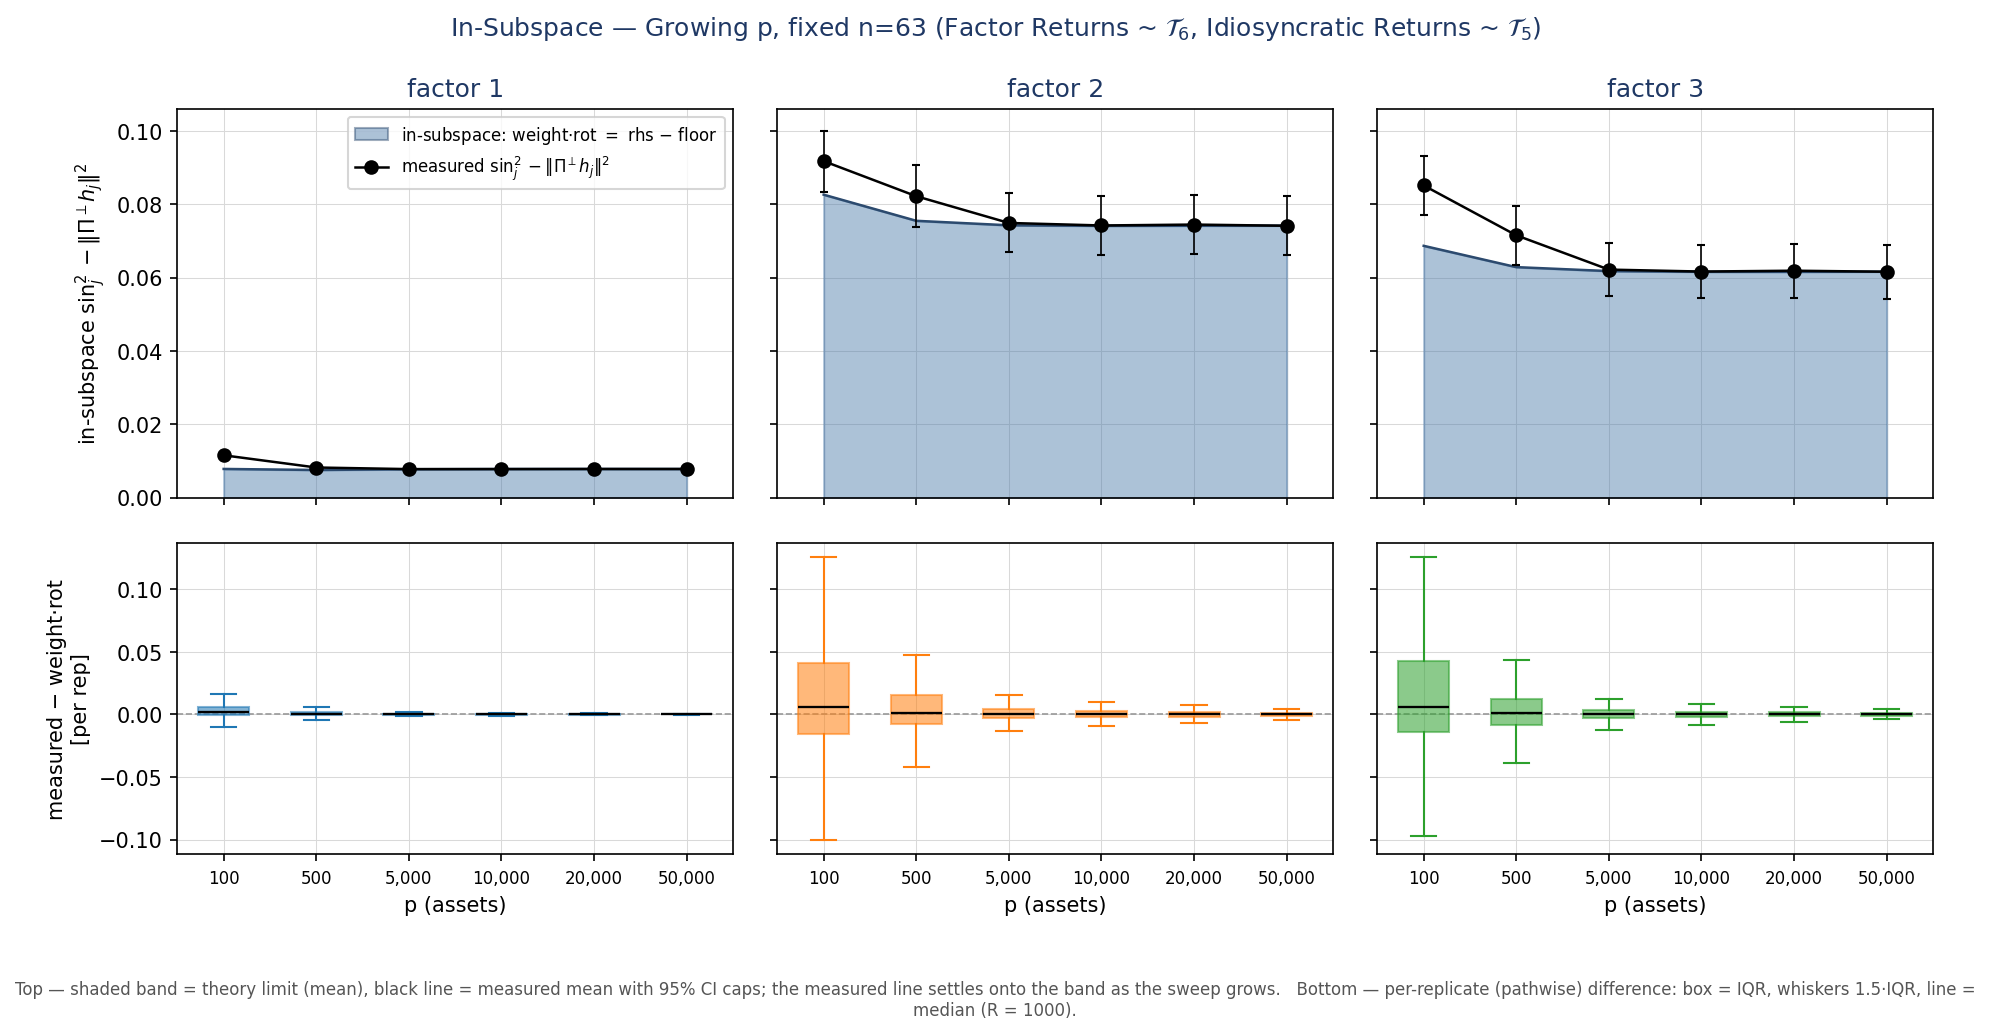

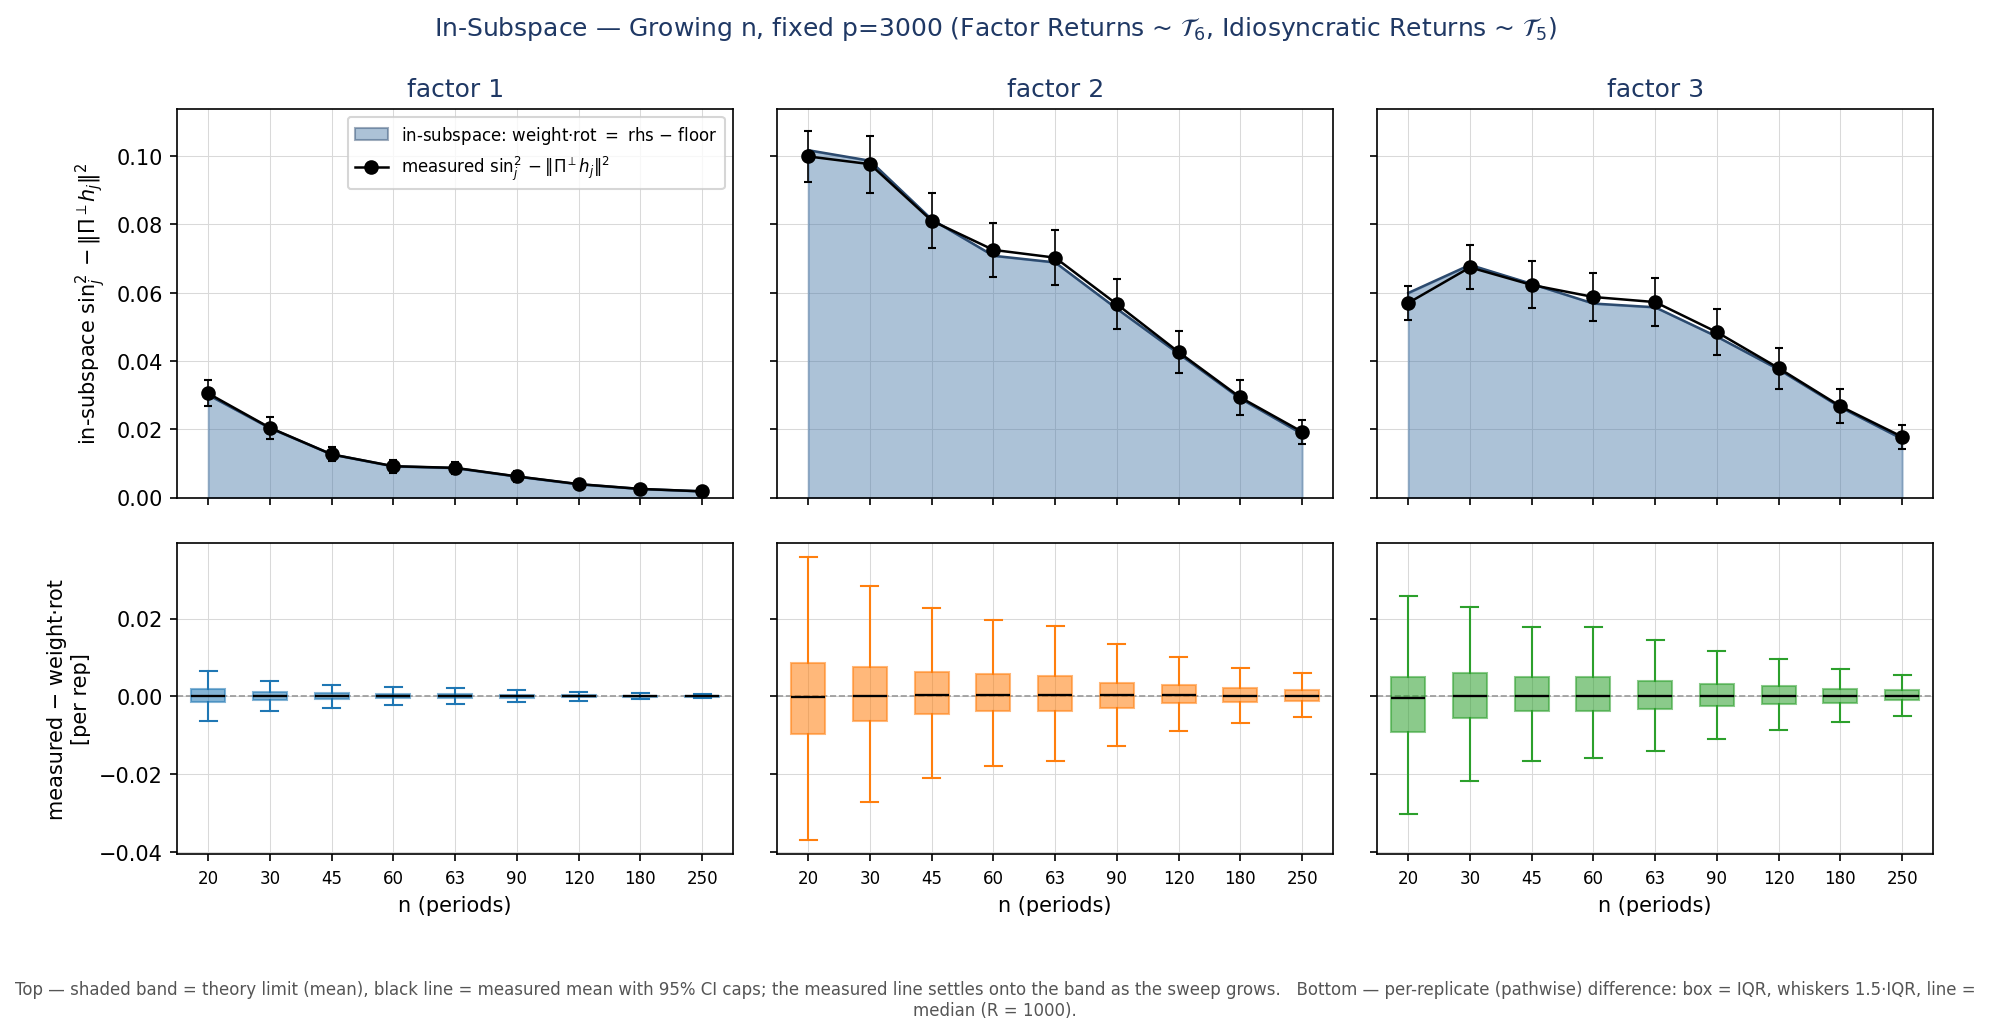

In [11]:
# ── Figure 4 of 4: IN-SUBSPACE — measured settling onto the weight·rot band ──
for key, cdf, lab in _SWEEPS:
    _png = OUT_DIR / f"ex2v2_comp4_insub_growing_{key}.png"
    fig, _ = component_two_row(
        cdf, key,
        meas_col="measured_in_subspace", theory_col="theory_insub", diff_col="diff_insub",
        # fill=_INSUB_FILL, topline=_INSUB_LINE,
        fill=_OOS_FILL, topline=_OOS_LINE,
        meas_label=r"measured $\sin^2_j - \Vert\Pi^{\perp}h_j\Vert^2$",
        theory_label=r"in-subspace: weight$\cdot$rot $=$ rhs $-$ floor",
        top_ylabel=r"in-subspace $\sin^2_j-\Vert\Pi^{\perp}h_j\Vert^2$",
        bottom_ylabel="measured − weight·rot\n[per rep]",
        out_path=str(_png),
        suptitle=rf"In-Subspace — {lab} {_TAILS}")
    fig.savefig(OUT_DIR / f"ex2v2_comp4_insub_growing_{key}.pdf", bbox_inches="tight")
    display(Image(filename=str(_png)))
    plt.close(fig)

In [ ]:
# ── In-subspace rotation: sin²∠(Π h_j, b_j), growing p at fixed n=63 ──────────
# The in-subspace summand of the exact split — how far the *projected* estimate
# Π h_j = bb'h_j sits from the population direction b_j, i.e. the misalignment that remains
# after the out-of-subspace mass is removed. It only reads distributionally (per-replicate
# values span [0,1] at every p), so the figure shows the per-replicate distribution as
# standard boxplots (show_violin=True re-enables the violin row).
#
# Recovered from columns already in the frame by rearranging the exact split:
#   sin²∠(h_j,b_j) = ‖Π⊥h_j‖² + (1−‖Π⊥h_j‖²)·sin²∠(Π h_j,b_j)
#   ⇒ sin²∠(Π h_j,b_j) = (sin²_j − ‖Π⊥h_j‖²) / (1 − ‖Π⊥h_j‖²)
# so it works on the current sweep; once `angle_in_subspace` is in the frame the two are
# cross-checked below and must agree to machine precision.
#
# Overlaid: the k×k rotation sin²∠(ν̂_j, e_j) (the `rotation` column), which is the p→∞ limit
# of this quantity — flat in p, so the in-subspace distribution should settle onto it.
# Pass overlay_col="sin2_j" instead to compare against the total angle.


def _np_gap_violin_panel(ax, dists, x, cats, color, *, clip=(0.005, 0.995), width=0.8,
                         zero_line=True):
    """Violin twin of fl_graphics._np_gap_box_panel — same signature, KDE body instead of a box.

    Body is the Gaussian KDE over the inner 99% of replicates (heavy tails would otherwise
    stretch the panel, the way the boxplots hide the same mass via showfliers=False); each
    violin is normalized to a common max width. Inner summary is computed on the untrimmed
    sample: thin line = 1.5·IQR range, thick bar = IQR, white dot = median.
    """
    if zero_line:
        ax.axhline(0, color="0.6", lw=0.8, ls="--", zorder=1)
    bodies, positions = [], []
    for arr, xi in zip(dists, x):
        a = np.asarray(arr, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:
            continue
        q1, med, q3 = np.quantile(a, [0.25, 0.5, 0.75])
        iqr = q3 - q1
        inside = a[(a >= q1 - 1.5 * iqr) & (a <= q3 + 1.5 * iqr)]
        lo, hi = (inside.min(), inside.max()) if inside.size else (med, med)
        body = a
        if clip is not None and a.size > 1:
            c_lo, c_hi = np.quantile(a, clip)
            body = a[(a >= c_lo) & (a <= c_hi)]
        if body.size >= 2 and np.ptp(body) > 0:
            bodies.append(body)
            positions.append(xi)
        else:
            ax.plot([xi - width / 2, xi + width / 2], [med, med], color=color, lw=1.6, zorder=3)
        ax.vlines(xi, lo, hi, color="0.25", lw=0.9, zorder=5)
        ax.vlines(xi, q1, q3, color="0.15", lw=4.0, zorder=6)
        ax.plot([xi], [med], marker="o", ms=3.0, mfc="white", mec="0.15", mew=0.7, zorder=7)
    if bodies:
        parts = ax.violinplot(bodies, positions=positions, widths=width,
                              showextrema=False, showmedians=False)
        for b in parts["bodies"]:
            b.set_facecolor(color)
            b.set_edgecolor(color)
            b.set_alpha(0.45)
            b.set_linewidth(0.8)
            b.set_zorder(3)
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.set_xticks(x, cats, fontsize=8)


def in_subspace_rotation(df):
    """Per-replicate sin²∠(Π h_j, b_j) from the recorded components of the exact split."""
    oos = df["measured_out_of_subspace"]
    return (df["sin2_j"] - oos) / (1.0 - oos)


_OVERLAY_COLOR = "#b5651d"


def box_over_violin(df, key, col, *, overlay_col=None, overlay_label=None, show_violin=False,
                    suptitle=None, out_path=None, ylabel=""):
    """Per-replicate distribution of ``col`` per swept value, columns = factors 1–3.

    Default is a single row of standard boxplots; ``show_violin=True`` adds a second row
    drawing the same data as violins on the same shared y-scale. ``overlay_col`` draws a
    second per-replicate quantity's median (dashed line) and Q1–Q3 (translucent band) over
    every panel, for comparison against the same axis.
    """
    order = sorted(df[key].unique())
    cats = [f"{v:,}" for v in order] if key == "p" else [str(v) for v in order]
    xlabel = "p (assets)" if key == "p" else "n (periods)"
    reps = int(df.groupby(["n", "p", "j"]).size().iloc[0])
    x = np.arange(len(cats))

    nrows = 2 if show_violin else 1
    fig, axes = plt.subplots(nrows, 3, figsize=(13.3, 7.4 if show_violin else 4.6),
                             sharex="col", sharey=True, squeeze=False)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.87 if show_violin else 0.82,
                        bottom=0.16 if show_violin else 0.24, hspace=0.13, wspace=0.08)
    for j in (1, 2, 3):
        sub = df[df["j"] == j]
        dists = [sub[sub[key] == v][col].to_numpy() for v in order]
        _np_gap_box_panel(axes[0, j - 1], dists, x, cats, _NP_COLORS[j - 1])
        if show_violin:
            _np_gap_violin_panel(axes[1, j - 1], dists, x, cats, _NP_COLORS[j - 1])
        if overlay_col is not None:
            ov = [sub[sub[key] == v][overlay_col].to_numpy() for v in order]
            q1 = np.array([np.quantile(a, 0.25) for a in ov])
            q3 = np.array([np.quantile(a, 0.75) for a in ov])
            md = np.array([np.median(a) for a in ov])
            for row in range(nrows):
                ax = axes[row, j - 1]
                ax.fill_between(x, q1, q3, color=_OVERLAY_COLOR, alpha=0.18, lw=0, zorder=8)
                ax.plot(x, md, "--", color=_OVERLAY_COLOR, lw=1.8, zorder=9)
                ax.plot(x, md, "o", color=_OVERLAY_COLOR, ms=3.5, zorder=9)
        axes[0, j - 1].set_title(f"factor {j}", color=_NP_NAVY)
        axes[-1, j - 1].set_xlabel(xlabel)
    axes[0, 0].set_ylim(0, 1)
    if show_violin:
        axes[0, 0].set_ylabel("boxplot\n" + ylabel)
        axes[1, 0].set_ylabel("violin\n" + ylabel)
    else:
        axes[0, 0].set_ylabel(ylabel)
    if overlay_col is not None:
        axes[0, 0].legend(handles=[
            plt.Line2D([], [], color=_NP_COLORS[0], lw=6, alpha=0.55, label=f"{ylabel} (per rep)"),
            plt.Line2D([], [], color=_OVERLAY_COLOR, lw=1.8, ls="--", marker="o", ms=3.5,
                       label=f"{overlay_label or overlay_col} median"),
            plt.Line2D([], [], color=_OVERLAY_COLOR, lw=6, alpha=0.25,
                       label=f"{overlay_label or overlay_col} Q1–Q3"),
        ], fontsize=7.5, loc="upper right")
    for ax in axes.flat:
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.label_outer()
    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY, y=0.95)
    overlay_note = ("" if overlay_col is None else
                    f"   Overlaid — {overlay_label or overlay_col}: dashed line = median, "
                    "translucent band = Q1–Q3.")
    violin_note = ("   Bottom — violin = KDE over the inner 99% of replicates, thick bar = IQR, "
                   "thin bar = 1.5·IQR range, white dot = median." if show_violin else "")
    fig.text(0.5, 0.045 if show_violin else 0.07,
             "Per-replicate distribution per swept value: box = IQR, whiskers 1.5·IQR, "
             f"line = median, fliers hidden (R = {reps}).{violin_note}{overlay_note}",
             ha="center", va="top", fontsize=8, color=_NP_GRAY, wrap=True)
    if out_path is not None:
        fig.savefig(str(out_path), dpi=150, bbox_inches="tight")
    return fig, axes


_ins = df_p.assign(sin2_in=in_subspace_rotation(df_p))

# Cross-check against the directly recorded angle, once the sweep has been re-run with it.
if "angle_in_subspace" in _ins.columns:
    _delta = (np.sin(_ins["angle_in_subspace"]) ** 2 - _ins["sin2_in"]).abs().max()
    print(f"recorded angle vs identity from the exact split: max |diff| = {_delta:.2e}")
else:
    print("note: 'angle_in_subspace' not in this sweep — using the exact-split identity "
          "(re-run the sweep cell to enable the cross-check)")

_ins_png = OUT_DIR / "ex2v2_insub_rotation_growing_p.png"
fig_ins, _ = box_over_violin(
    _ins, "p", "sin2_in", overlay_col="rotation",
    overlay_label=r"$\sin^2\angle(\hat\nu_j,e_j)$", out_path=str(_ins_png),
    ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$",
    suptitle=rf"In-subspace rotation $\sin^2\angle(\Pi h_j, b_j)$ vs the $k\times k$ rotation "
             rf"$\sin^2\angle(\hat\nu_j,e_j)$ — growing p, fixed n=63 {_TAILS}")
fig_ins.savefig(OUT_DIR / "ex2v2_insub_rotation_growing_p.pdf", bbox_inches="tight")
display(Image(filename=str(_ins_png)))
plt.close(fig_ins)

# Numbers behind the figure, with the overlay's median alongside.
display(_ins.groupby(["p", "j"])
            .agg(median=("sin2_in", "median"),
                 q1=("sin2_in", lambda s: s.quantile(0.25)),
                 q3=("sin2_in", lambda s: s.quantile(0.75)),
                 p95=("sin2_in", lambda s: s.quantile(0.95)),
                 max=("sin2_in", "max"),
                 rotation_median=("rotation", "median"))
            .round(4))


In [ ]:
# ── Same quantity, growing n at fixed p=3000 ─────────────────────────────────
# The p-sweep above plateaus: once the out-of-subspace mass is divided out, what remains is
# the finite-n rotation, which p cannot fix. This sweep is the one that should shrink — and it
# identifies n, not p, as the axis that controls the in-subspace misalignment. The overlaid
# k×k rotation now decays too, since it is the same finite-n effect seen in the factor space.
_ins_n = df_n.assign(sin2_in=in_subspace_rotation(df_n))

_ins_n_png = OUT_DIR / "ex2v2_insub_rotation_growing_n.png"
fig_ins_n, _ = box_over_violin(
    _ins_n, "n", "sin2_in", overlay_col="rotation",
    overlay_label=r"$\sin^2\angle(\hat\nu_j,e_j)$", out_path=str(_ins_n_png),
    ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$",
    suptitle=rf"In-subspace rotation $\sin^2\angle(\Pi h_j, b_j)$ vs the $k\times k$ rotation "
             rf"$\sin^2\angle(\hat\nu_j,e_j)$ — growing n, fixed p=3000 {_TAILS}")
fig_ins_n.savefig(OUT_DIR / "ex2v2_insub_rotation_growing_n.pdf", bbox_inches="tight")
display(Image(filename=str(_ins_n_png)))
plt.close(fig_ins_n)

# Median plus the upper tail: the median is small at every n, but the tail mass is what
# actually decays. P(sin² > 0.5) means the projected estimate is >45° from b_j — which for
# factors 2 and 3 is a 2↔3 swap (their spikes ρ ∝ c_jσ_j² are only 1.77× apart, so the
# individual eigenvectors are ill-conditioned at small n even though their span is not).
_tail = (_ins_n.groupby(["n", "j"])["sin2_in"]
              .agg(median="median", p90=lambda s: s.quantile(0.90),
                   frac_gt_0_1=lambda s: (s > 0.10).mean(),
                   frac_gt_0_5=lambda s: (s > 0.50).mean())
              .round(4))
display(_tail)
